# Evaluación comparativa del método Chain-Ladder clásico y versiones robustas para estimar el IBNR bajo contaminación controlada

Este cuaderno presenta el experimento principal del trabajo. El objetivo es comparar el desempeño del método Chain-Ladder clásico frente a tres variantes robustas en la estimación del IBNR cuando los triángulos de desarrollo contienen valores atípicos controlados.

La validación previa del simulador se documenta en un cuaderno separado: `validacion_simulador_ibnr.ipynb`. En este archivo se parte de esa validación y se desarrolla el análisis central: definición de escenarios, ejecución Monte Carlo, cálculo de métricas, comparación entre métodos e interpretación de resultados.

## Estructura general del cuaderno

El desarrollo se organiza para seguir el orden del experimento final, sin mezclarlo con la prueba interna del simulador:

1. **Planteamiento del estudio.** Se presentan la pregunta, el objetivo y las hipótesis de trabajo.
2. **Diseño experimental.** Se fijan la dimensión del triángulo, los supuestos de simulación y la matriz de escenarios.
3. **Métodos de estimación.** Se definen el Chain-Ladder clásico y las variantes robustas que serán comparadas.
4. **Experimento Monte Carlo.** Se ejecutan las réplicas bajo los escenarios definidos.
5. **Evaluación de resultados.** Se calculan métricas, clasificaciones y comparaciones pareadas frente al método clásico.
6. **Conclusiones.** Se conectan los resultados con las hipótesis y con la pregunta de investigación.

La prueba del simulador no se elimina del proyecto; queda separada para que funcione como soporte metodológico previo y no interrumpa la lectura del experimento principal.

## Planteamiento del estudio

**Pregunta de investigación.** ¿Bajo qué combinaciones de proporción, magnitud y ubicación de la contaminación las variantes robustas del método Chain-Ladder superan al enfoque clásico en la estimación del IBNR?

**Objetivo general.** Comparar el desempeño del método Chain-Ladder clásico y de tres variantes robustas en la estimación del IBNR bajo escenarios controlados de contaminación, con el fin de identificar en qué condiciones los enfoques robustos ofrecen mejoras en precisión y estabilidad.

**Hipótesis de trabajo.**

- H1. En escenarios contaminados, el desempeño del método Chain-Ladder clásico se deteriora a medida que aumentan la proporción y la magnitud de la contaminación, mientras que al menos una variante robusta conserva menor error y menor variabilidad relativa.

La hipótesis se contrasta al final del cuaderno mediante métricas de error, desviación estándar, clasificaciones por escenario, resúmenes por familias de contaminación y comparaciones pareadas sobre las mismas réplicas simuladas.


## Fundamento teórico y criterio de diseño

La literatura actuarial establece que el Chain-Ladder clásico es altamente sensible a observaciones atípicas. Mack (1993) formaliza el marco estocástico del método y muestra cómo cuantificar el error de predicción. England y Verrall (2002) destacan que la principal ventaja de los modelos estocásticos de reserving es la disponibilidad de medidas explícitas de precisión. Verdonck et al. (2009) y Verdonck y Debruyne (2011) muestran, desde la perspectiva de robustez e influencia, que incluso una sola observación extrema puede desplazar de forma importante la reserva estimada. Más recientemente, Avanzi et al. (2024) profundizan en la sensibilidad posicional del reserving frente a outliers y documentan que las celdas cercanas a la frontera observada pueden ejercer una influencia particularmente alta.

A partir de ese marco, el diseño implementado adopta una lógica deliberadamente comparativa: el IBNR real se conoce por construcción, la contaminación se introduce únicamente sobre la región observable y los métodos compiten sobre los mismos triángulos simulados. Esta estructura produce comparaciones pareadas, reduce el ruido Monte Carlo en las diferencias entre métodos y permite una lectura más sólida de la evidencia empírica.

## Ruta metodológica del experimento principal

El experimento principal se desarrolla como una secuencia de pasos que conviene leer en orden:

1. Se fijan la dimensión del triángulo, la distribución de base y los parámetros del proceso generador.
2. Se construye la matriz de escenarios con base en la proporción, la magnitud y la ubicación de la contaminación.
3. Se simulan triángulos incrementales completos y se obtiene su versión acumulada.
4. Se define la región observada y se calcula el IBNR verdadero en la zona futura no observada.
5. Se introduce contaminación solo en la región observable del triángulo incremental.
6. Se estiman los factores de desarrollo y el IBNR con el método clásico y con las variantes robustas.
7. Se repite el procedimiento para todas las réplicas y todos los escenarios del diseño.
8. Se resumen los resultados con métricas de error, clasificaciones por escenario y comparaciones pareadas frente al método clásico.

La validación del simulador corresponde a una etapa previa y separada. Su función es verificar que la simulación respeta los supuestos del estudio. Por esa razón se documenta en `validacion_simulador_ibnr.ipynb` y no dentro de los resultados finales.

## Entorno computacional y reproducibilidad

La implementación se apoya en librerías de uso estándar para simulación, análisis tabular y visualización:

- `numpy`: simulación aleatoria, álgebra matricial y operaciones vectorizadas.
- `pandas`: organización tabular de réplicas, escenarios y métricas.
- `matplotlib` y `seaborn`: visualización de resultados.
- `pathlib`: manejo portable de rutas del repositorio.

El código reutilizable se encuentra en `fuente/proyecto_ibnr`. Este cuaderno concentra el experimento principal y la discusión de resultados, mientras que la validación del simulador queda documentada por separado. La semilla aleatoria se fija de forma explícita para garantizar reproducibilidad.

In [1]:
# Preparación de rutas del proyecto
from pathlib import Path
import sys

RAIZ = Path.cwd()
if not (RAIZ / "fuente").exists() and (RAIZ.parent / "fuente").exists():
    RAIZ = RAIZ.parent
FUENTE = RAIZ / "fuente"
if str(FUENTE) not in sys.path:
    sys.path.append(str(FUENTE))

DIRECTORIO_RESULTADOS = RAIZ / "resultados"
DIRECTORIO_RESULTADOS.mkdir(parents=True, exist_ok=True)

In [2]:

# Librerías y funciones necesarias para el experimento principal
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")
    ip.run_line_magic("config", "InlineBackend.figure_format = 'png'")


from proyecto_ibnr.configuracion import construir_configuracion_base, construir_escenarios_base, clonar_configuracion
from proyecto_ibnr.diagnosticos import (
    construir_tabla_conteo_ratios,
    calcular_estadisticas_acumuladas,
    resumir_dominancia_metodos,
)
from proyecto_ibnr.evaluacion import (
    ETIQUETAS_METODOS,
    evaluar_hipotesis_principal,
    comparar_metodos_con_base,
    calcular_metricas_metodos,
    clasificar_metodos_en_escenario,
    resumir_resultados_familia,
)
from proyecto_ibnr.experimento import construir_resumen_global, ejecutar_experimento
from proyecto_ibnr.metodos import estimar_ibnr_todos_metodos
from proyecto_ibnr.simulacion import mascara_observada, simular_un_triangulo

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.unicode_minus"] = False


In [3]:

# Funciones auxiliares para la lectura visual y la exportación de figuras.
DIRECTORIO_FIGURAS_PRESENTACION = RAIZ / "presentacion" / "figuras"
DIRECTORIO_FIGURAS_PRESENTACION.mkdir(parents=True, exist_ok=True)

ORDEN_METODOS = ["clasico", "mediana", "ponderado", "truncada"]
PALETA_METODOS = {
    "clasico": "#8E96A1",
    "mediana": "#1E6A86",
    "ponderado": "#67808F",
    "truncada": "#C8CED6",
}
ETIQUETAS_METODOS_PRESENTACION = [ETIQUETAS_METODOS[metodo] for metodo in ORDEN_METODOS]
ORDEN_UBICACION = {"ninguna": -1, "temprana": 0, "tardia": 1, "aleatoria": 2}
ETIQUETAS_UBICACION = {
    "ninguna": "Sin contaminación",
    "temprana": "Temprana",
    "tardia": "Tardía",
    "aleatoria": "Aleatoria",
}


def guardar_figura(figura, nombre_archivo: str) -> Path:
    "Guarda una figura con estilo homogéneo en la carpeta de presentación."
    ruta_salida = DIRECTORIO_FIGURAS_PRESENTACION / nombre_archivo
    figura.savefig(ruta_salida, dpi=220, bbox_inches="tight", facecolor="white")
    return ruta_salida


def formatear_miles(valor: float) -> str:
    "Convierte números en un formato legible para la presentación."
    return f"{valor:,.0f}".replace(",", ".")


def formatear_escenario(etiqueta_escenario: str) -> str:
    "Pasa el código del escenario a una etiqueta corta y legible."
    if etiqueta_escenario == "base_sin_contaminacion":
        return "Base sin contaminación"
    proporcion, magnitud, ubicacion = etiqueta_escenario.split("_", 2)
    return f"{proporcion[1:]}% · ×{magnitud[1:]} · {ETIQUETAS_UBICACION.get(ubicacion, ubicacion.title())}"


def ordenar_escenarios(metricas_fuente: pd.DataFrame) -> list[str]:
    "Define un orden natural: base primero y luego por proporción, magnitud y ubicación."
    tabla_orden = (
        metricas_fuente[[
            "escenario",
            "proporcion_contaminacion",
            "magnitud_contaminacion",
            "ubicacion_contaminacion",
        ]]
        .drop_duplicates()
        .assign(
            orden_base=lambda df: np.where(df["escenario"].eq("base_sin_contaminacion"), -1, 0),
            orden_ubicacion=lambda df: df["ubicacion_contaminacion"].map(ORDEN_UBICACION).fillna(9),
        )
        .sort_values(
            ["orden_base", "proporcion_contaminacion", "magnitud_contaminacion", "orden_ubicacion", "escenario"]
        )
    )
    return tabla_orden["escenario"].tolist()


def graficar_barra_y_mapa_calor(
    metricas_fuente: pd.DataFrame,
    metrica: str,
    titulo_barra: str,
    titulo_mapa: str,
    etiqueta_eje_y: str,
    etiqueta_barra_color: str,
    nombre_archivo: str,
    cmap: str = "YlGnBu",
) -> pd.DataFrame:
    "Construye una figura con barra-resumen y mapa de calor por escenario."
    resumen = (
        metricas_fuente.groupby("metodo", as_index=False)[metrica]
        .mean()
        .set_index("metodo")
        .loc[ORDEN_METODOS]
        .reset_index()
    )
    escenarios_ordenados = ordenar_escenarios(metricas_fuente)
    matriz = (
        metricas_fuente.pivot_table(index="escenario", columns="metodo", values=metrica)
        .reindex(index=escenarios_ordenados, columns=ORDEN_METODOS)
        .rename(index=formatear_escenario, columns=ETIQUETAS_METODOS)
    )

    figura, ejes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1.0, 1.35]})

    barras = ejes[0].bar(
        ETIQUETAS_METODOS_PRESENTACION,
        resumen[metrica],
        color=[PALETA_METODOS[metodo] for metodo in ORDEN_METODOS],
        width=0.68,
    )
    for barra, valor in zip(barras, resumen[metrica]):
        ejes[0].text(
            barra.get_x() + barra.get_width() / 2,
            valor + resumen[metrica].max() * 0.03,
            formatear_miles(valor),
            ha="center",
            va="bottom",
            fontsize=10,
        )
    ejes[0].set_title(titulo_barra)
    ejes[0].set_xlabel("Método")
    ejes[0].set_ylabel(etiqueta_eje_y)
    ejes[0].spines[["top", "right"]].set_visible(False)
    ejes[0].grid(axis="y", alpha=0.18)

    sns.heatmap(
        matriz,
        cmap=cmap,
        linewidths=0.25,
        linecolor="white",
        cbar_kws={"label": etiqueta_barra_color},
        ax=ejes[1],
    )
    ejes[1].set_title(titulo_mapa)
    ejes[1].set_xlabel("Método")
    ejes[1].set_ylabel("Escenario")
    ejes[1].tick_params(axis="y", labelsize=8)
    ejes[1].tick_params(axis="x", rotation=0)

    plt.tight_layout()
    guardar_figura(figura, nombre_archivo)
    plt.show()
    return resumen


def construir_tabla_familias_metricas(metricas_fuente: pd.DataFrame, metrica: str, etiqueta_valor: str) -> pd.DataFrame:
    "Resume cada familia con una lectura doble: mejor promedio y mayor frecuencia ganadora."
    especificaciones = [
        ("Sin contaminación", metricas_fuente["escenario"].eq("base_sin_contaminacion")),
        ("Contaminación del 5%", metricas_fuente["proporcion_contaminacion"].eq(0.05)),
        ("Contaminación del 10%", metricas_fuente["proporcion_contaminacion"].eq(0.10)),
        ("Contaminación del 20%", metricas_fuente["proporcion_contaminacion"].eq(0.20)),
        ("Outliers ×2", metricas_fuente["magnitud_contaminacion"].eq(2.0)),
        ("Outliers ×5", metricas_fuente["magnitud_contaminacion"].eq(5.0)),
        ("Outliers ×10", metricas_fuente["magnitud_contaminacion"].eq(10.0)),
        ("Contaminación temprana", metricas_fuente["ubicacion_contaminacion"].eq("temprana")),
        ("Contaminación tardía", metricas_fuente["ubicacion_contaminacion"].eq("tardia")),
        ("Contaminación aleatoria", metricas_fuente["ubicacion_contaminacion"].eq("aleatoria")),
    ]

    filas = []
    for familia, filtro in especificaciones:
        bloque = metricas_fuente.loc[filtro].copy()
        mejores_promedios = (
            bloque.groupby("metodo", as_index=False)[metrica]
            .mean()
            .sort_values(metrica)
            .reset_index(drop=True)
        )
        ganadores_por_escenario = (
            bloque.sort_values(["escenario", metrica, "metodo"])
            .groupby("escenario", as_index=False)
            .first()
            .groupby("metodo")
            .size()
            .sort_values(ascending=False)
        )
        filas.append(
            {
                "Familia": familia,
                "Método con mejor promedio": ETIQUETAS_METODOS[mejores_promedios.loc[0, "metodo"]],
                etiqueta_valor: round(float(mejores_promedios.loc[0, metrica]), 2),
                "Método con más escenarios ganados": ETIQUETAS_METODOS[ganadores_por_escenario.index[0]],
                "Frecuencia ganadora": f"{int(ganadores_por_escenario.iloc[0])}/{int(ganadores_por_escenario.sum())}",
            }
        )
    return pd.DataFrame(filas)


def resumir_estabilidad_final(acumulado_fuente: pd.DataFrame, inicio_tramo: int) -> float:
    "Calcula qué tanto fluctúa el RMSE acumulado en el tramo final de la curva."
    tramo = acumulado_fuente.loc[acumulado_fuente["replica"] >= inicio_tramo, "rmse_acumulado"]
    valor_final = acumulado_fuente["rmse_acumulado"].iloc[-1]
    return 100 * (tramo.max() - tramo.min()) / valor_final


def graficar_convergencia_doble(
    resultados_fuente: pd.DataFrame,
    escenario_referencia: str,
    metodo_referencia: str,
    escenario_contraste: str,
    metodo_contraste: str,
    nombre_archivo: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    "Muestra la convergencia del RMSE acumulado en dos escenarios contrastantes."
    acumulado_referencia = calcular_estadisticas_acumuladas(resultados_fuente, escenario_referencia, metodo_referencia)
    acumulado_contraste = calcular_estadisticas_acumuladas(resultados_fuente, escenario_contraste, metodo_contraste)

    figura, ejes = plt.subplots(1, 2, figsize=(14, 4.8))
    configuracion = [
        (acumulado_referencia, f"Convergencia del RMSE acumulado | {formatear_escenario(escenario_referencia)} - {ETIQUETAS_METODOS[metodo_referencia]}", "#1E6A86"),
        (acumulado_contraste, f"Convergencia del RMSE acumulado | {formatear_escenario(escenario_contraste)} - {ETIQUETAS_METODOS[metodo_contraste]}", "#A33C30"),
    ]
    for eje, (tabla, titulo, color) in zip(ejes, configuracion):
        eje.plot(tabla["replica"], tabla["rmse_acumulado"], color=color, linewidth=1.6)
        eje.set_title(titulo)
        eje.set_xlabel("Número de réplicas")
        eje.set_ylabel("RMSE acumulado")
        eje.spines[["top", "right"]].set_visible(False)
        eje.grid(alpha=0.20)
    plt.tight_layout()
    guardar_figura(figura, nombre_archivo)
    plt.show()
    return acumulado_referencia, acumulado_contraste


def graficar_boxplots_representativos(
    resultados_fuente: pd.DataFrame,
    escenarios_seleccionados: list[str],
    titulo_general: str,
    nombre_archivo: str,
) -> None:
    "Compara la distribución del error porcentual en cuatro escenarios representativos."
    datos_plot = resultados_fuente.loc[resultados_fuente["escenario"].isin(escenarios_seleccionados)].copy()
    datos_plot["error_porcentual_pct"] = 100 * datos_plot["error_porcentual"]

    figura, ejes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
    ejes = ejes.flatten()
    for eje, escenario in zip(ejes, escenarios_seleccionados):
        subconjunto = datos_plot.loc[datos_plot["escenario"] == escenario].copy()
        sns.boxplot(
            data=subconjunto,
            x="metodo",
            y="error_porcentual_pct",
            hue="metodo",
            order=ORDEN_METODOS,
            hue_order=ORDEN_METODOS,
            palette=PALETA_METODOS,
            dodge=False,
            width=0.65,
            linewidth=1,
            ax=eje,
        )
        if eje.get_legend() is not None:
            eje.get_legend().remove()
        eje.axhline(0.0, color="#444444", linestyle="--", linewidth=1)
        eje.set_title(formatear_escenario(escenario))
        eje.set_xlabel("Método")
        eje.set_ylabel("Error porcentual (%)")
        eje.set_xticks(range(len(ORDEN_METODOS)))
        eje.set_xticklabels(ETIQUETAS_METODOS_PRESENTACION, rotation=0)
        eje.spines[["top", "right"]].set_visible(False)
        eje.grid(axis="y", alpha=0.15)
    figura.suptitle(titulo_general, y=1.02)
    plt.tight_layout()
    guardar_figura(figura, nombre_archivo)
    plt.show()


## Configuración experimental

El experimento se implementa sobre triángulos de dimensión `10 × 10`, donde las filas representan años de ocurrencia y las columnas periodos de desarrollo. Esta dimensión permite trabajar con un horizonte completo de diez años sin producir un costo computacional excesivo para las réplicas Monte Carlo.

Los montos incrementales se generan con esperanza `E[X_{i,j}] = μ_i d_j` y varianza `Var(X_{i,j}) = φ (μ_i d_j)^2`. El patrón acumulado se fija de forma exógena y de él se derivan las proporciones incrementales esperadas.

In [4]:

# Definición de parámetros base y escenarios del experimento
SEMILLA = 20260429
configuracion = construir_configuracion_base(semilla_aleatoria=SEMILLA, distribucion="gamma")
escenarios = construir_escenarios_base()
mascara = mascara_observada(configuracion.n_periodos)

tabla_escenarios = pd.DataFrame([escenario.__dict__ for escenario in escenarios])
tabla_escenarios


,nombre,proporcion,magnitud,ubicacion
0,base_sin_contaminacion,0.0000,1.0000,ninguna
1,p5_m2_aleatoria,0.0500,2.0000,aleatoria
2,p5_m2_temprana,0.0500,2.0000,temprana
3,p5_m2_tardia,0.0500,2.0000,tardia
4,p5_m5_aleatoria,0.0500,5.0000,aleatoria
5,p5_m5_temprana,0.0500,5.0000,temprana
6,p5_m5_tardia,0.0500,5.0000,tardia
7,p5_m10_aleatoria,0.0500,10.0000,aleatoria
8,p5_m10_temprana,0.0500,10.0000,temprana
9,p5_m10_tardia,0.0500,10.0000,tardia


La tabla anterior contiene la matriz completa de escenarios. El experimento combina tres dimensiones de contaminación:

- **Proporción de celdas contaminadas**: `0%`, `5%`, `10%` y `20%`.
- **Magnitud del outlier**: multiplicación por `1`, `2`, `5` y `10`. El factor `1` solo aparece en el escenario base, donde no hay contaminación efectiva.
- **Ubicación de la contaminación**:
  - `aleatoria`: selección aleatoria dentro de la región observable;
  - `temprana`: primer tercio de celdas observadas de cada fila;
  - `tardia`: último tercio de celdas observadas de cada fila.

De esta forma, el estudio no se limita a distinguir entre “con” y “sin” outliers, sino que explora cuánto cambia el desempeño del reserving cuando la contaminación es más frecuente, más intensa o aparece cerca de la frontera observada.

## Justificación de decisiones metodológicas

Las decisiones centrales del diseño se resumen a continuación para dejar explícito qué se hizo y cuál es su papel dentro del estudio.

In [5]:
# Resumen de las principales decisiones metodológicas del experimento
justification_df = pd.DataFrame(
    [
        {
            "decision": "Triángulos 10 × 10",
            "justificacion": "Es una dimensión clásica en reserving, suficiente para reproducir una zona observada y una zona futura relevantes sin volver innecesariamente pesado el experimento.",
            "papel_en_el_estudio": "Permite comparar métodos con una estructura triangular completa y con número decreciente de ratios por periodo.",
        },
        {
            "decision": "1000 réplicas en el caso base",
            "justificacion": "Se busca estabilizar métricas como RMSE, MAPE y desviación estándar sin perder viabilidad computacional.",
            "papel_en_el_estudio": "Sostiene la comparación Monte Carlo entre métodos y escenarios.",
        },
        {
            "decision": "Distribución Gamma como caso base",
            "justificacion": "Genera montos positivos y asimétricos, compatibles con pagos incrementales, y permite controlar media y dispersión de forma directa.",
            "papel_en_el_estudio": "Define el escenario principal del experimento.",
        },
        {
            "decision": "Sensibilidad Lognormal",
            "justificacion": "Permite revisar si los hallazgos cambian cuando la distribución subyacente tiene colas más pesadas.",
            "papel_en_el_estudio": "Evalúa la estabilidad de las conclusiones frente a un mecanismo alternativo de simulación.",
        },
        {
            "decision": "Contaminación positiva y multiplicativa",
            "justificacion": "Aísla el efecto de observaciones influyentes de gran magnitud sobre los factores de desarrollo.",
            "papel_en_el_estudio": "Permite medir cómo se distorsiona el IBNR cuando los datos observados contienen outliers.",
        },
        {
            "decision": "Proporciones 5 %, 10 % y 20 %",
            "justificacion": "Representan niveles bajo, intermedio y alto de contaminación para estudiar sensibilidad de manera gradual.",
            "papel_en_el_estudio": "Distingue entre contaminación escasa, moderada y frecuente.",
        },
        {
            "decision": "Magnitudes ×2, ×5 y ×10",
            "justificacion": "Representan outliers moderados, intensos y severos dentro de una regla de contaminación fácil de interpretar.",
            "papel_en_el_estudio": "Permite separar el efecto de la frecuencia del efecto de la severidad.",
        },
        {
            "decision": "Media truncada al 10 %",
            "justificacion": "Se adopta como regla robusta moderada, aunque en triángulos pequeños su efecto práctico puede ser limitado por el bajo número de ratios por periodo.",
            "papel_en_el_estudio": "Sirve como variante intermedia entre el promedio clásico y reglas más resistentes como la mediana.",
        },
    ]
)

justification_df

,decision,justificacion,papel_en_el_estudio
0,Triángulos 10 × 10,"Es una dimensión clásica en reserving, suficiente para reproducir una zona observada y una zona futura relevantes sin volver innecesaria...",Permite comparar métodos con una estructura triangular completa y con número decreciente de ratios por periodo.
1,1000 réplicas en el caso base,"Se busca estabilizar métricas como RMSE, MAPE y desviación estándar sin perder viabilidad computacional.",Sostiene la comparación Monte Carlo entre métodos y escenarios.
2,Distribución Gamma como caso base,"Genera montos positivos y asimétricos, compatibles con pagos incrementales, y permite controlar media y dispersión de forma directa.",Define el escenario principal del experimento.
3,Sensibilidad Lognormal,Permite revisar si los hallazgos cambian cuando la distribución subyacente tiene colas más pesadas.,Evalúa la estabilidad de las conclusiones frente a un mecanismo alternativo de simulación.
4,Contaminación positiva y multiplicativa,Aísla el efecto de observaciones influyentes de gran magnitud sobre los factores de desarrollo.,Permite medir cómo se distorsiona el IBNR cuando los datos observados contienen outliers.
5,"Proporciones 5 %, 10 % y 20 %","Representan niveles bajo, intermedio y alto de contaminación para estudiar sensibilidad de manera gradual.","Distingue entre contaminación escasa, moderada y frecuente."
6,"Magnitudes ×2, ×5 y ×10","Representan outliers moderados, intensos y severos dentro de una regla de contaminación fácil de interpretar.",Permite separar el efecto de la frecuencia del efecto de la severidad.
7,Media truncada al 10 %,"Se adopta como regla robusta moderada, aunque en triángulos pequeños su efecto práctico puede ser limitado por el bajo número de ratios ...",Sirve como variante intermedia entre el promedio clásico y reglas más resistentes como la mediana.


In [6]:
# Resumen de las dimensiones usadas para construir los escenarios
diseno_escenarios_df = pd.DataFrame(
    {
        "componente": ["Proporción", "Magnitud", "Ubicación"],
        "niveles": ["0%, 5%, 10%, 20%", "x1, x2, x5, x10", "ninguna, aleatoria, temprana, tardia"],
        "interpretación": [
            "Determina qué fracción de las celdas observadas es alterada.",
            "Determina cuán extremo se vuelve cada valor atípico seleccionado.",
            "Determina si la contaminación ocurre al inicio, al final o de forma dispersa en el desarrollo.",
        ],
    }
)
diseno_escenarios_df

,componente,niveles,interpretación
0,Proporción,"0%, 5%, 10%, 20%",Determina qué fracción de las celdas observadas es alterada.
1,Magnitud,"x1, x2, x5, x10",Determina cuán extremo se vuelve cada valor atípico seleccionado.
2,Ubicación,"ninguna, aleatoria, temprana, tardia","Determina si la contaminación ocurre al inicio, al final o de forma dispersa en el desarrollo."


In [7]:
# Revisión de los parámetros de desarrollo usados en la simulación
parameter_overview = pd.DataFrame(
    {
        "periodo_desarrollo": np.arange(1, configuracion.n_periodos + 1),
        "proporcion_acumulada": configuracion.desarrollo_acumulado,
        "proporcion_incremental": configuracion.desarrollo_incremental,
    }
)

print("Semilla:", configuracion.semilla_aleatoria)
print("Distribución base:", configuracion.distribucion)
print("Dispersión phi:", configuracion.dispersion_phi)
print("Ultimates esperados por año de ocurrencia:", np.round(configuracion.medias_ultimas, 2))
parameter_overview

Semilla: 20260429
Distribución base: gamma
Dispersión phi: 0.3
Ultimates esperados por año de ocurrencia: [1025.13 1061.65 1099.46 1138.63 1179.18 1221.18 1264.68 1309.73 1356.38
 1404.7 ]


,periodo_desarrollo,proporcion_acumulada,proporcion_incremental
0,1,0.4500,0.4500
1,2,0.7000,0.2500
2,3,0.8200,0.1200
3,4,0.9000,0.0800
4,5,0.9500,0.0500
5,6,0.9700,0.0200
6,7,0.9850,0.0150
7,8,0.9930,0.0080
8,9,0.9980,0.0050
9,10,1.0000,0.0020


El modelo base puede resumirse en la forma

$$
\begin{aligned}
X_{i,j} &\sim \mathrm{Gamma}(\alpha_{i,j}, \beta_{i,j}), \\
\mathbb{E}[X_{i,j}] &= \mu_i d_j, \\
\mathrm{Var}(X_{i,j}) &= \phi (\mu_i d_j)^2.
\end{aligned}
$$

Aquí, $\mu_i$ representa el nivel esperado último del año de ocurrencia $i$, $d_j$ representa la fracción incremental esperada del periodo de desarrollo $j$ y $\phi$ controla la dispersión relativa. El patrón acumulado fija la forma general del desarrollo, mientras que los $\mu_i$ introducen heterogeneidad entre filas. Esta combinación permite generar triángulos plausibles sin perder trazabilidad estadística.

## Tamaño muestral de los ratios de desarrollo

Antes de aplicar los métodos, se revisa cuántos ratios individuales quedan disponibles por periodo de desarrollo. Esta información es relevante porque las variantes robustas estiman factores mediante mediana, media truncada o ponderación robusta, y su estabilidad depende del número de ratios disponibles en cada periodo.

In [8]:
# Conteo de ratios disponibles por periodo de desarrollo
ratio_count_df = construir_tabla_conteo_ratios(mascara)
ratio_count_df

,periodo_desarrollo,n_ratios_individuales
0,1,9
1,2,8
2,3,7
3,4,6
4,5,5
5,6,4
6,7,3
7,8,2
8,9,1


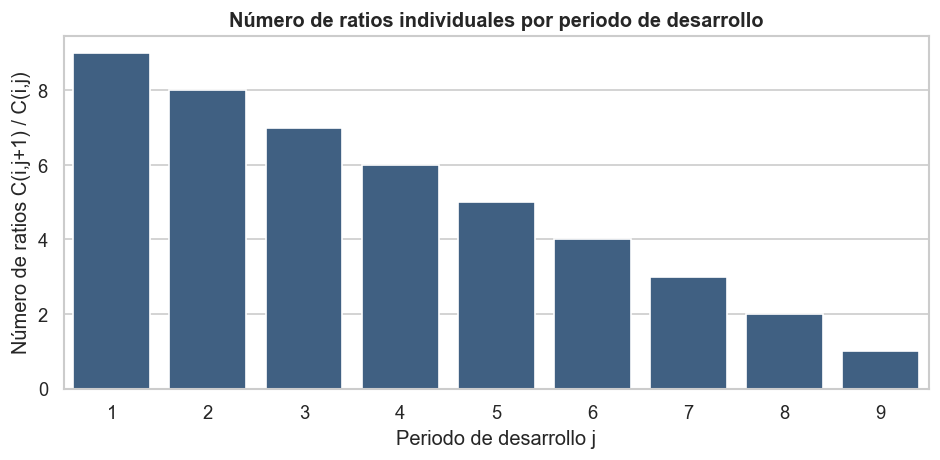

In [9]:
# Visualización del número de ratios usados para estimar factores de desarrollo
plt.figure(figsize=(8, 4))
sns.barplot(data=ratio_count_df, x="periodo_desarrollo", y="n_ratios_individuales", color="#35608d")
plt.title("Número de ratios individuales por periodo de desarrollo")
plt.xlabel("Periodo de desarrollo j")
plt.ylabel("Número de ratios C(i,j+1) / C(i,j)")
plt.tight_layout()
plt.show()

## Métodos de estimación

Se comparan cuatro formas de estimar los factores de desarrollo y el IBNR:

- **Chain-Ladder clásico:** usa el promedio ponderado tradicional de los ratios de desarrollo.
- **Chain-Ladder con mediana:** reemplaza el promedio por la mediana de los ratios individuales para reducir el efecto de valores extremos.
- **Chain-Ladder con media truncada:** elimina una proporción de ratios en los extremos antes de calcular el promedio.
- **Chain-Ladder ponderado robusto:** reduce el peso de ratios alejados del comportamiento central mediante una escala robusta.

Todos los métodos se aplican sobre los mismos triángulos observados en cada réplica. Por ello, las diferencias de desempeño se atribuyen al método de estimación y no a cambios en los datos de entrada.

En términos operativos, el procedimiento de estimación sigue tres pasos:

1. Calcular ratios individuales de desarrollo a partir del triángulo acumulado observado.
2. Estimar factores agregados de desarrollo con cada método.
3. Proyectar la parte futura del triángulo y calcular el IBNR estimado.

La siguiente celda muestra una verificación mínima de salida para una réplica ilustrativa. La revisión completa del simulador está en el notebook de validación.

In [10]:
# Verificación mínima de los métodos sobre una réplica ilustrativa
generador_vista_previa = np.random.default_rng(SEMILLA)
ejemplo_vista_previa = simular_un_triangulo(configuracion, escenarios[4], generador_vista_previa)
estimaciones_vista_previa = estimar_ibnr_todos_metodos(ejemplo_vista_previa.acumulado_observado, configuracion)
estimaciones_vista_previa

{'clasico': EstimacionMetodo(metodo='clasico', factores=array([1.42175115, 1.39685277, 1.11013151, 1.03983434, 1.02979596,
        1.01805519, 1.00214649, 1.00545565, 1.00197832]), acumulado_proyectado=array([[ 293.76889062,  417.08335487,  462.35221488,  563.57653425,
          581.92112939,  615.1248984 ,  630.47884711,  634.17060987,
          637.07710429,  638.33744554],
        [ 258.89739168,  450.9342232 , 1806.47923715, 1912.92192317,
         1929.06877874, 1961.02590515, 1984.27749084, 1985.7011212 ,
         1997.08772456, 2001.03859959],
        [ 554.78376222, 1037.91526985, 1136.69752638, 1230.35626916,
         1309.9262638 , 1376.55490252, 1395.2083174 , 1398.70025445,
         1406.3310706 , 1409.11324098],
        [ 575.44743576,  774.28158129,  936.43955547, 1059.68665146,
         1158.7282141 , 1193.07766135, 1228.72680746, 1231.36425148,
         1238.08214131, 1240.53146177],
        [ 427.34475988,  794.42109374,  914.10644077, 1014.75646848,
         1055.2672

## Diseño Monte Carlo y estructura pareada

El experimento principal usa `1000` réplicas para cada escenario bajo distribución Gamma. En cada réplica, los cuatro métodos se aplican sobre el mismo triángulo observado. Esta estructura genera comparaciones pareadas: cada diferencia entre métodos se calcula con la misma información simulada, lo que reduce el ruido de comparación y permite evaluar directamente el efecto del método de estimación.

In [11]:

# Ejecución del experimento Monte Carlo principal
NUMERO_REPLICAS = 1000
resultados_df = ejecutar_experimento(configuracion, escenarios, n_replicas=NUMERO_REPLICAS)

# Se construyen columnas auxiliares en español para que las métricas queden trazables.
resultados_df["error"] = resultados_df["ibnr_estimado"] - resultados_df["ibnr_real"]
resultados_df["error_absoluto"] = np.abs(resultados_df["error"])
resultados_df["error_porcentual"] = resultados_df["error"] / resultados_df["ibnr_real"]
resultados_df["error_porcentual_absoluto"] = np.abs(resultados_df["error_porcentual"])

metadatos_escenarios = (
    resultados_df.groupby("escenario", as_index=False)
    .agg(
        proporcion_contaminacion=("proporcion_contaminacion", "first"),
        magnitud_contaminacion=("magnitud_contaminacion", "first"),
        ubicacion_contaminacion=("ubicacion_contaminacion", "first"),
    )
    .sort_values("escenario")
    .reset_index(drop=True)
)

# Escenarios ancla para las visualizaciones de la sustentación.
ESCENARIO_BASE = "base_sin_contaminacion"
ESCENARIO_CONTAMINACION_LEVE = "p5_m2_aleatoria"
ESCENARIO_CONTAMINACION_INTERMEDIA = "p10_m5_aleatoria"
ESCENARIO_CONTAMINACION_MAXIMA = "p20_m10_aleatoria"
ESCENARIOS_REPRESENTATIVOS = [
    ESCENARIO_BASE,
    ESCENARIO_CONTAMINACION_LEVE,
    ESCENARIO_CONTAMINACION_INTERMEDIA,
    ESCENARIO_CONTAMINACION_MAXIMA,
]

resultados_df.head()


,escenario,replica,metodo,ibnr_real,ibnr_estimado,proporcion_contaminacion,magnitud_contaminacion,ubicacion_contaminacion,error,error_absoluto,error_porcentual,error_porcentual_absoluto
0,base_sin_contaminacion,1,clasico,"1,467.9280",651.9076,0.0000,1.0000,ninguna,-816.0204,816.0204,-0.5559,0.5559
1,base_sin_contaminacion,1,mediana,"1,467.9280",681.1630,0.0000,1.0000,ninguna,-786.7650,786.7650,-0.5360,0.5360
2,base_sin_contaminacion,1,truncada,"1,467.9280",871.5033,0.0000,1.0000,ninguna,-596.4246,596.4246,-0.4063,0.4063
3,base_sin_contaminacion,1,ponderado,"1,467.9280",758.5295,0.0000,1.0000,ninguna,-709.3985,709.3985,-0.4833,0.4833
4,base_sin_contaminacion,2,clasico,"1,262.6102","1,854.5701",0.0000,1.0000,ninguna,591.9598,591.9598,0.4688,0.4688


## Métricas principales

El desempeño se resume mediante sesgo, MSE, RMSE, MAE, MAPE, error porcentual medio y desviación estándar de las estimaciones. Para las métricas basadas en promedios también se reporta una aproximación al error estándar Monte Carlo y un intervalo de confianza normal aproximado. El RMSE permanece como métrica principal de comparación, por su lectura directa en la escala del IBNR.

Las métricas principales se interpretan del siguiente modo:

$$
\begin{aligned}
\mathrm{Bias} &= \frac{1}{N}\sum_{s=1}^{N}(\widehat{IBNR}_s - IBNR_s), \\
\mathrm{RMSE} &= \sqrt{\frac{1}{N}\sum_{s=1}^{N}(\widehat{IBNR}_s - IBNR_s)^2}.
\end{aligned}
$$

$$
\begin{aligned}
\mathrm{MAPE} &= \frac{1}{N}\sum_{s=1}^{N}\left|\frac{\widehat{IBNR}_s - IBNR_s}{IBNR_s}\right|, \\
\operatorname{SD}(\widehat{IBNR}) &= \sqrt{\frac{1}{N-1}\sum_{s=1}^{N}(\widehat{IBNR}_s - \overline{\widehat{IBNR}})^2}.
\end{aligned}
$$

- Un **RMSE** menor indica mejor precisión global.
- Un **MAPE** menor indica menor error relativo medio.
- Un **sesgo** cercano a cero indica ausencia de sobreestimación o subestimación sistemática.
- Una **desviación estándar** menor indica mayor estabilidad entre réplicas.

Por ello, un método favorable no es necesariamente el que minimiza una sola métrica, sino el que presenta un compromiso razonable entre precisión, estabilidad y comportamiento sistemático.

In [12]:
# Cálculo de métricas de desempeño por método y escenario
metricas_df = calcular_metricas_metodos(resultados_df)
if not {"proporcion_contaminacion", "magnitud_contaminacion", "ubicacion_contaminacion"}.issubset(metricas_df.columns):
    metricas_df = metricas_df.merge(metadatos_escenarios, on="escenario", how="left")
metricas_df.head(12)


,escenario,metodo,proporcion_contaminacion,magnitud_contaminacion,ubicacion_contaminacion,n_replicas,sesgo,mse,rmse,mae,mape,error_porcentual_promedio,desviacion_estandar_estimaciones,tasa_sobreestimacion,tasa_subestimacion,error_absoluto_mediano,error_estandar_monte_carlo_sesgo,error_estandar_monte_carlo_mape,error_estandar_monte_carlo_mae,sesgo_ic_inferior,sesgo_ic_superior,mape_ic_inferior,mape_ic_superior,mae_ic_inferior,mae_ic_superior
0,base_sin_contaminacion,clasico,0.0000,1.0000,ninguna,"1,000.0000",47.8495,"360,505.7581",600.4213,452.3592,0.2751,0.0549,540.0131,0.5040,0.4960,361.8414,18.9361,0.0082,12.4913,10.7348,84.9642,0.2591,0.2911,427.8762,476.8422
1,base_sin_contaminacion,mediana,0.0000,1.0000,ninguna,"1,000.0000",22.5031,"393,494.1473",627.2911,474.8475,0.2876,0.0394,569.8795,0.4650,0.5350,380.2450,19.8338,0.0083,12.9685,-16.3713,61.3774,0.2713,0.3038,449.4292,500.2658
2,base_sin_contaminacion,ponderado,0.0000,1.0000,ninguna,"1,000.0000",153.3182,"469,633.6673",685.2982,507.5875,0.3117,0.1197,615.7929,0.5520,0.4480,391.5364,21.1323,0.0096,14.5671,111.8989,194.7375,0.2929,0.3304,479.0359,536.1390
3,base_sin_contaminacion,truncada,0.0000,1.0000,ninguna,"1,000.0000",432.5280,"824,240.4961",907.8769,659.2060,0.4107,0.2897,762.3297,0.6940,0.3060,487.7201,25.2547,0.0129,19.7504,383.0289,482.0272,0.3854,0.4359,620.4952,697.9167
4,p10_m10_aleatoria,clasico,0.1000,10.0000,aleatoria,"1,000.0000","2,572.0961","26,261,214.7344","5,124.5697","2,731.3345",1.6890,1.5994,"4,429.7021",0.8210,0.1790,"1,381.9898",140.2327,0.0868,137.1854,"2,297.2401","2,846.9522",1.5188,1.8592,"2,462.4510","3,000.2180"
5,p10_m10_aleatoria,mediana,0.1000,10.0000,aleatoria,"1,000.0000","1,508.1343","12,412,364.9262","3,523.1186","1,741.7343",1.0748,0.9457,"3,179.0978",0.7160,0.2840,731.6282,100.7375,0.0610,96.8923,"1,310.6888","1,705.5798",0.9552,1.1943,"1,551.8254","1,931.6432"
6,p10_m10_aleatoria,ponderado,0.1000,10.0000,aleatoria,"1,000.0000","1,999.6928","17,337,178.6535","4,163.7938","2,140.4883",1.3224,1.2456,"3,649.7360",0.8150,0.1850,973.6507,115.5498,0.0708,112.9967,"1,773.2152","2,226.1705",1.1836,1.4612,"1,919.0148","2,361.9619"
7,p10_m10_aleatoria,truncada,0.1000,10.0000,aleatoria,"1,000.0000","5,830.0828","115,900,432.2907","10,765.7063","5,839.5893",3.5750,3.5701,"9,061.8976",0.9850,0.0150,"3,254.5049",286.3434,0.1745,286.1495,"5,268.8496","6,391.3159",3.2330,3.9170,"5,278.7364","6,400.4422"
8,p10_m10_tardia,clasico,0.1000,10.0000,tardia,"1,000.0000","1,885.2093","19,867,199.6677","4,457.2637","1,970.4181",1.2292,1.1853,"4,027.9277",0.8530,0.1470,847.4180,127.7870,0.0780,126.4937,"1,634.7468","2,135.6718",1.0762,1.3821,"1,722.4904","2,218.3457"
9,p10_m10_tardia,mediana,0.1000,10.0000,tardia,"1,000.0000","1,207.2485","14,818,131.2219","3,849.4326","1,464.2952",0.9069,0.7677,"3,644.2281",0.6530,0.3470,507.5552,115.6463,0.0682,112.6351,980.5818,"1,433.9151",0.7733,1.0405,"1,243.5305","1,685.0599"


In [13]:
# Ranking de métodos según RMSE y resumen global de desempeño
clasificacion_df = clasificar_metodos_en_escenario(metricas_df, metrica="rmse")
dominancia_df = resumir_dominancia_metodos(clasificacion_df)
resumen_global = construir_resumen_global(metricas_df)

print("Método ganador por número de escenarios:")
display(dominancia_df)
print("Resumen global por método:")
display(resumen_global)

Método ganador por número de escenarios:


,metodo,escenarios_ganados
0,mediana,17
1,clasico,11


Resumen global por método:


,metodo,rmse_promedio,mape_promedio,sesgo_absoluto_promedio,desviacion_estandar_promedio
0,mediana,"1,858.7110",0.6241,649.0613,"1,692.4732"
1,ponderado,"2,166.3624",0.7316,911.8454,"1,921.9900"
2,clasico,"2,229.1016",0.7727,927.5342,"1,968.0474"
3,truncada,"3,944.8316",1.3993,"2,128.0778","3,288.3559"


Las dos tablas anteriores cumplen funciones distintas. La primera cuenta cuántos escenarios gana cada método cuando el criterio de comparación es el RMSE. La segunda resume su comportamiento promedio en el conjunto total del experimento. La combinación de ambas tablas permite separar dos preguntas distintas: qué método domina globalmente y qué método conserva ventajas en escenarios específicos.

In [14]:

# Resumen comparativo entre escenario limpio y escenarios contaminados
resumen_limpio_contaminado = (
    metricas_df.assign(
        entorno=lambda df: np.where(df["escenario"].eq("base_sin_contaminacion"), "Sin contaminación", "Escenarios contaminados")
    )
    .groupby(["entorno", "metodo"], as_index=False)
    .agg(
        rmse_promedio=("rmse", "mean"),
        mape_promedio=("mape", "mean"),
        desviacion_estandar_promedio=("desviacion_estandar_estimaciones", "mean"),
    )
)

mejor_por_escenario = (
    clasificacion_df.loc[
        clasificacion_df["rango"] == 1,
        [
            "escenario",
            "metodo",
            "rmse",
            "mape",
            "sesgo",
            "proporcion_contaminacion",
            "magnitud_contaminacion",
            "ubicacion_contaminacion",
        ],
    ]
    .sort_values(["proporcion_contaminacion", "magnitud_contaminacion", "ubicacion_contaminacion"])
    .reset_index(drop=True)
)

print("Resumen por entorno:")
display(resumen_limpio_contaminado)
print("Método ganador por escenario:")
display(mejor_por_escenario.head(15))


Resumen por entorno:


,entorno,metodo,rmse_promedio,mape_promedio,desviacion_estandar_promedio
0,Escenarios contaminados,clasico,"2,289.4231",0.7911,"2,020.9375"
1,Escenarios contaminados,mediana,"1,904.3191",0.6366,"1,734.0507"
2,Escenarios contaminados,ponderado,"2,221.2167",0.7471,"1,970.3676"
3,Escenarios contaminados,truncada,"4,057.3114",1.4359,"3,381.9124"
4,Sin contaminación,clasico,600.4213,0.2751,540.0131
5,Sin contaminación,mediana,627.2911,0.2876,569.8795
6,Sin contaminación,ponderado,685.2982,0.3117,615.7929
7,Sin contaminación,truncada,907.8769,0.4107,762.3297


Método ganador por escenario:


,escenario,metodo,rmse,mape,sesgo,proporcion_contaminacion,magnitud_contaminacion,ubicacion_contaminacion
0,base_sin_contaminacion,clasico,600.4213,0.2751,47.8495,0.0000,1.0000,ninguna
1,p5_m2_aleatoria,mediana,742.5113,0.3346,106.6234,0.0500,2.0000,aleatoria
2,p5_m2_tardia,clasico,662.4432,0.3048,123.3113,0.0500,2.0000,tardia
3,p5_m2_temprana,clasico,636.7036,0.2964,59.9061,0.0500,2.0000,temprana
4,p5_m5_aleatoria,mediana,"1,276.2440",0.4549,354.3026,0.0500,5.0000,aleatoria
5,p5_m5_tardia,mediana,"1,170.4426",0.3933,244.3764,0.0500,5.0000,tardia
6,p5_m5_temprana,mediana,"1,078.3917",0.3893,149.7897,0.0500,5.0000,temprana
7,p5_m10_aleatoria,mediana,"2,485.8719",0.7067,805.1479,0.0500,10.0000,aleatoria
8,p5_m10_tardia,mediana,"2,095.5762",0.5347,496.6200,0.0500,10.0000,tardia
9,p5_m10_temprana,mediana,"1,815.8737",0.5084,385.6544,0.0500,10.0000,temprana


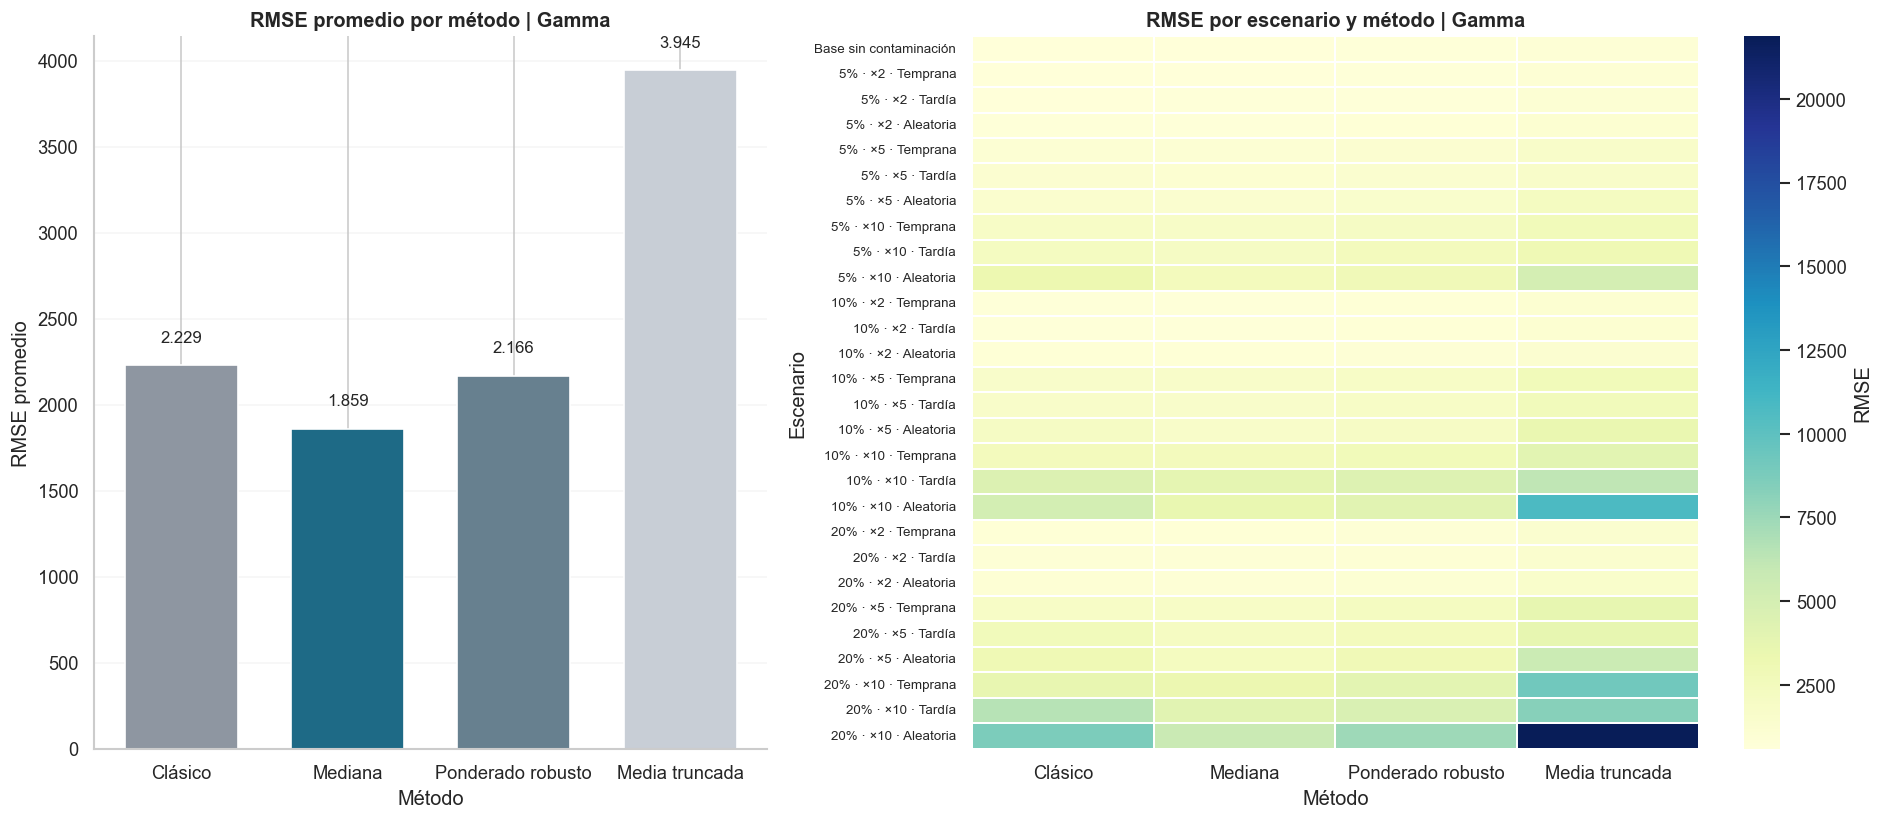

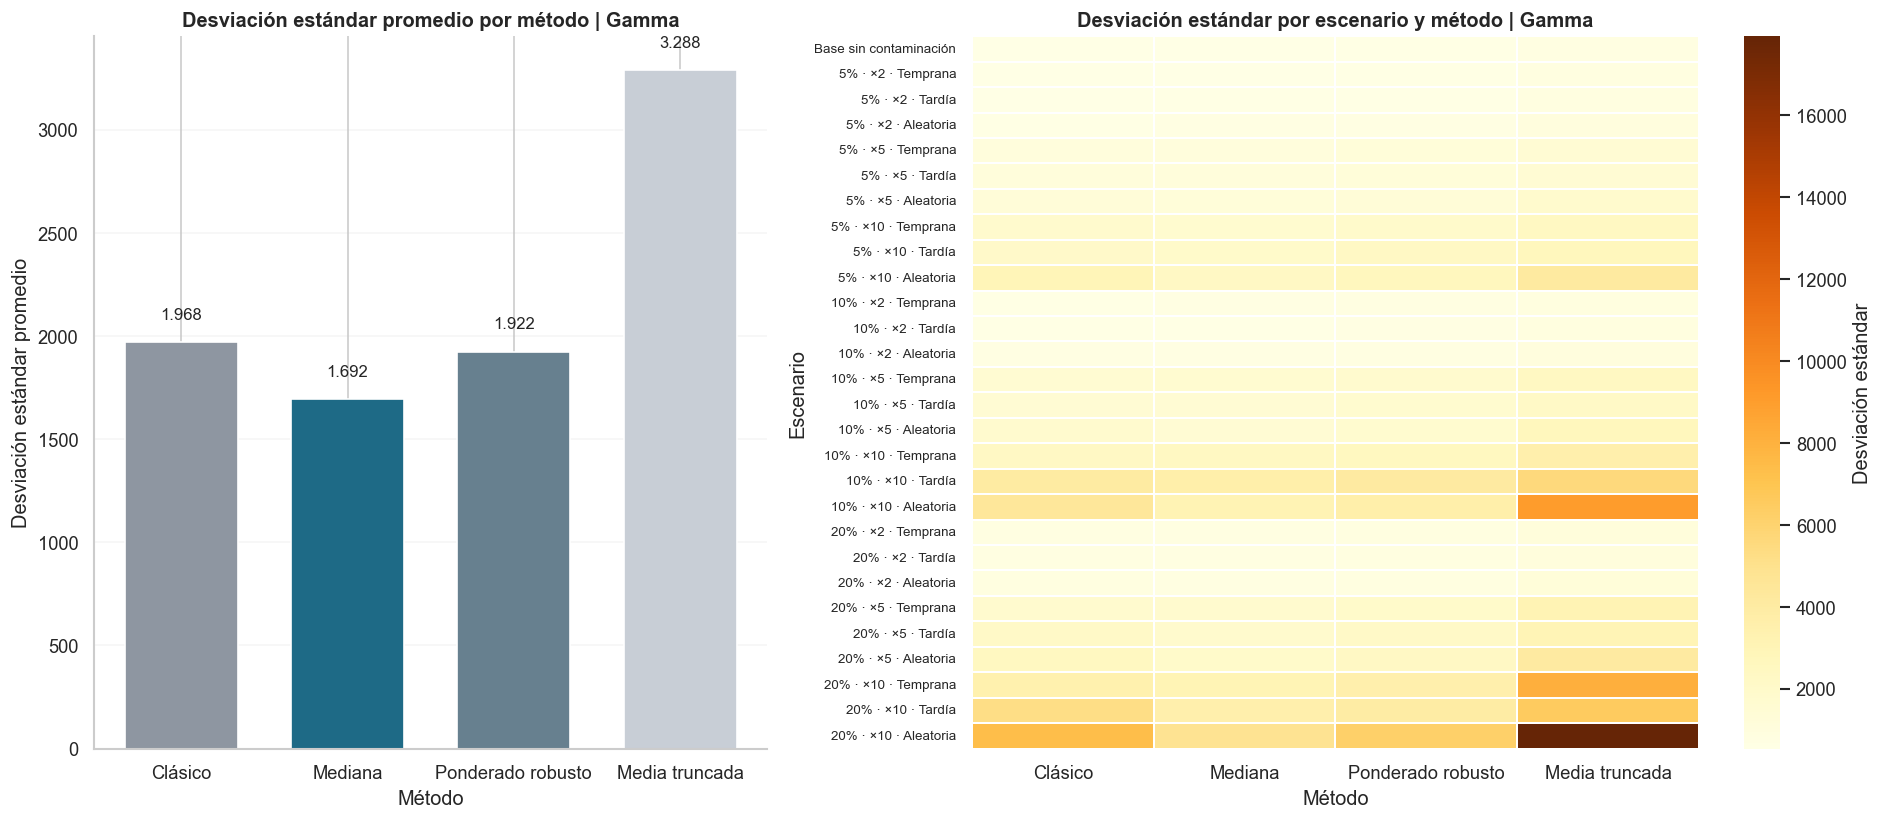

In [15]:

# Visualizaciones principales de RMSE y desviación estándar bajo Gamma
resumen_rmse_gamma = graficar_barra_y_mapa_calor(
    metricas_df,
    metrica="rmse",
    titulo_barra="RMSE promedio por método | Gamma",
    titulo_mapa="RMSE por escenario y método | Gamma",
    etiqueta_eje_y="RMSE promedio",
    etiqueta_barra_color="RMSE",
    nombre_archivo="rmse_gamma_barra_mapa.png",
    cmap="YlGnBu",
)

resumen_desviacion_gamma = graficar_barra_y_mapa_calor(
    metricas_df,
    metrica="desviacion_estandar_estimaciones",
    titulo_barra="Desviación estándar promedio por método | Gamma",
    titulo_mapa="Desviación estándar por escenario y método | Gamma",
    etiqueta_eje_y="Desviación estándar promedio",
    etiqueta_barra_color="Desviación estándar",
    nombre_archivo="desviacion_gamma_barra_mapa.png",
    cmap="YlOrBr",
)



La lectura conjunta de estas cuatro visualizaciones muestra dos ideas centrales del experimento base. Primero, la **mediana** logra el menor RMSE promedio global, mientras que la **media truncada** concentra los peores resultados cuando la contaminación aumenta. Segundo, la historia no se agota en el promedio: la desviación estándar confirma que el escenario limpio sigue favoreciendo al enfoque clásico, pero en los escenarios contaminados la mediana mantiene estimaciones más estables y con menor dispersión.

El mapa de calor también deja ver dónde aparece la frontera entre eficiencia y robustez. Las mayores tensiones se concentran en escenarios con **magnitud alta**, especialmente cuando la contaminación es aleatoria o alcanza el 20% de las celdas observadas. Esa lectura visual será útil más adelante para interpretar por qué la mediana domina en promedio, pero el método clásico todavía conserva algunas victorias puntuales.


## Comparaciones pareadas frente al método clásico

La evaluación anterior resume el desempeño medio por escenario. Sin embargo, dado que los métodos se aplican sobre las mismas réplicas, es posible comparar sus errores en forma pareada. Una diferencia negativa en `delta_mse_promedio` indica que el método robusto presenta menor error cuadrático medio que el método clásico en el mismo conjunto de réplicas.

In [16]:
# Comparación pareada de cada método robusto contra Chain-Ladder clásico
comparaciones_df = comparar_metodos_con_base(resultados_df, base="clasico")
comparaciones_df = comparaciones_df.merge(metadatos_escenarios, on="escenario", how="left")
comparaciones_df.head(12)

,escenario,metodo,base,n_replicas,delta_mse_promedio,delta_mse_error_estandar,delta_mse_ic_inferior,delta_mse_ic_superior,delta_mse_mejora,delta_mse_empeora,delta_mae_promedio,delta_mae_error_estandar,delta_mae_ic_inferior,delta_mae_ic_superior,delta_mae_mejora,delta_mae_empeora,delta_mape_promedio,delta_mape_error_estandar,delta_mape_ic_inferior,delta_mape_ic_superior,delta_mape_mejora,delta_mape_empeora,proporcion_contaminacion,magnitud_contaminacion,ubicacion_contaminacion
0,base_sin_contaminacion,mediana,clasico,1000,"32,988.3892","12,379.7178","8,724.1422","57,252.6361",False,True,22.4883,5.6994,11.3175,33.6591,False,True,0.0125,0.0035,0.0055,0.0194,False,True,0.0000,1.0000,ninguna
1,base_sin_contaminacion,ponderado,clasico,1000,"109,127.9091","16,502.7252","76,782.5678","141,473.2505",False,True,55.2283,6.1751,43.1251,67.3315,False,True,0.0366,0.0038,0.0292,0.0439,False,True,0.0000,1.0000,ninguna
2,base_sin_contaminacion,truncada,clasico,1000,"463,734.7380","46,803.7068","371,999.4726","555,470.0033",False,True,206.8468,13.6068,180.1774,233.5161,False,True,0.1356,0.0081,0.1196,0.1515,False,True,0.0000,1.0000,ninguna
3,p10_m10_aleatoria,mediana,clasico,1000,"-13,848,849.8082","2,294,480.1671","-18,346,030.9358","-9,351,668.6806",True,False,-989.6002,74.6688,"-1,135.9511",-843.2493,True,False,-0.6142,0.0461,-0.7045,-0.5240,True,False,0.1000,10.0000,aleatoria
4,p10_m10_aleatoria,ponderado,clasico,1000,"-8,924,036.0809","2,192,997.5659","-13,222,311.3101","-4,625,760.8518",True,False,-590.8462,67.9466,-724.0216,-457.6709,True,False,-0.3666,0.0419,-0.4487,-0.2845,True,False,0.1000,10.0000,aleatoria
5,p10_m10_aleatoria,truncada,clasico,1000,"89,639,217.5563","18,102,113.1418","54,159,075.7983","125,119,359.3142",False,True,"3,108.2548",188.8379,"2,738.1325","3,478.3770",False,True,1.8860,0.1125,1.6654,2.1065,False,True,0.1000,10.0000,aleatoria
6,p10_m10_tardia,mediana,clasico,1000,"-5,049,068.4458","1,514,116.7037","-8,016,737.1851","-2,081,399.7065",True,False,-506.1229,37.9037,-580.4141,-431.8316,True,False,-0.3223,0.0240,-0.3693,-0.2752,True,False,0.1000,10.0000,tardia
7,p10_m10_tardia,ponderado,clasico,1000,"-731,535.3220","1,166,575.9571","-3,018,024.1979","1,554,953.5540",False,False,-295.7070,31.1255,-356.7131,-234.7009,True,False,-0.1876,0.0193,-0.2254,-0.1497,True,False,0.1000,10.0000,tardia
8,p10_m10_tardia,truncada,clasico,1000,"18,645,999.6235","4,130,221.6286","10,550,765.2315","26,741,234.0155",False,True,790.1032,60.3362,671.8443,908.3621,False,True,0.4943,0.0386,0.4187,0.5700,False,True,0.1000,10.0000,tardia
9,p10_m10_temprana,mediana,clasico,1000,"289,473.3805","633,592.4446","-952,367.8109","1,531,314.5719",False,False,-27.3586,34.0117,-94.0214,39.3043,False,False,-0.0115,0.0213,-0.0532,0.0303,False,False,0.1000,10.0000,temprana


In [17]:
# Resumen de escenarios donde cada método robusto mejora o empeora frente al clásico
resumen_comparaciones = (
    comparaciones_df.groupby("metodo", as_index=False)
    .agg(
        escenarios_con_mejora_mse=("delta_mse_mejora", "sum"),
        escenarios_con_deterioro_mse=("delta_mse_empeora", "sum"),
        escenarios_con_mejora_mape=("delta_mape_mejora", "sum"),
        delta_mse_promedio=("delta_mse_promedio", "mean"),
        delta_mape_promedio=("delta_mape_promedio", "mean"),
    )
    .sort_values("escenarios_con_mejora_mse", ascending=False)
)
resumen_comparaciones

,metodo,escenarios_con_mejora_mse,escenarios_con_deterioro_mse,escenarios_con_mejora_mape,delta_mse_promedio,delta_mape_promedio
0,mediana,12,4,16,"-3,606,242.6036",-0.1486
1,ponderado,5,18,7,"-1,508,341.3861",-0.0411
2,truncada,0,28,0,"25,424,987.5673",0.6266


En esta tabla, una mejora significa que el método robusto reduce el error respecto del método clásico sobre las mismas réplicas. Por ejemplo, si `escenarios_con_mejora_mse` es alto para la mediana, ello indica que la ventaja observada no se debe solo a uno o dos escenarios extremos, sino a un patrón repetido en distintos contextos de contaminación. El criterio es descriptivo: se usa para identificar regularidades entre escenarios y no como prueba inferencial aislada para cada caso.


## Distribución del error porcentual en escenarios representativos

Para no saturar la presentación con los 28 escenarios completos, se seleccionan cuatro casos guía: el escenario base, una contaminación débil, una contaminación intermedia y una contaminación máxima. La idea es ver la **distribución completa del error porcentual**, no solo su promedio. Por eso se conserva la línea punteada en cero y se comparan simultáneamente posición, dispersión y colas de cada método.


,Escenario,Papel en la lectura
0,Base sin contaminación,Punto de referencia sin contaminación
1,5% · ×2 · Aleatoria,Contaminación leve para ver el costo de robustificar
2,10% · ×5 · Aleatoria,Zona de transición entre eficiencia y robustez
3,20% · ×10 · Aleatoria,Contaminación máxima para forzar el contraste entre métodos


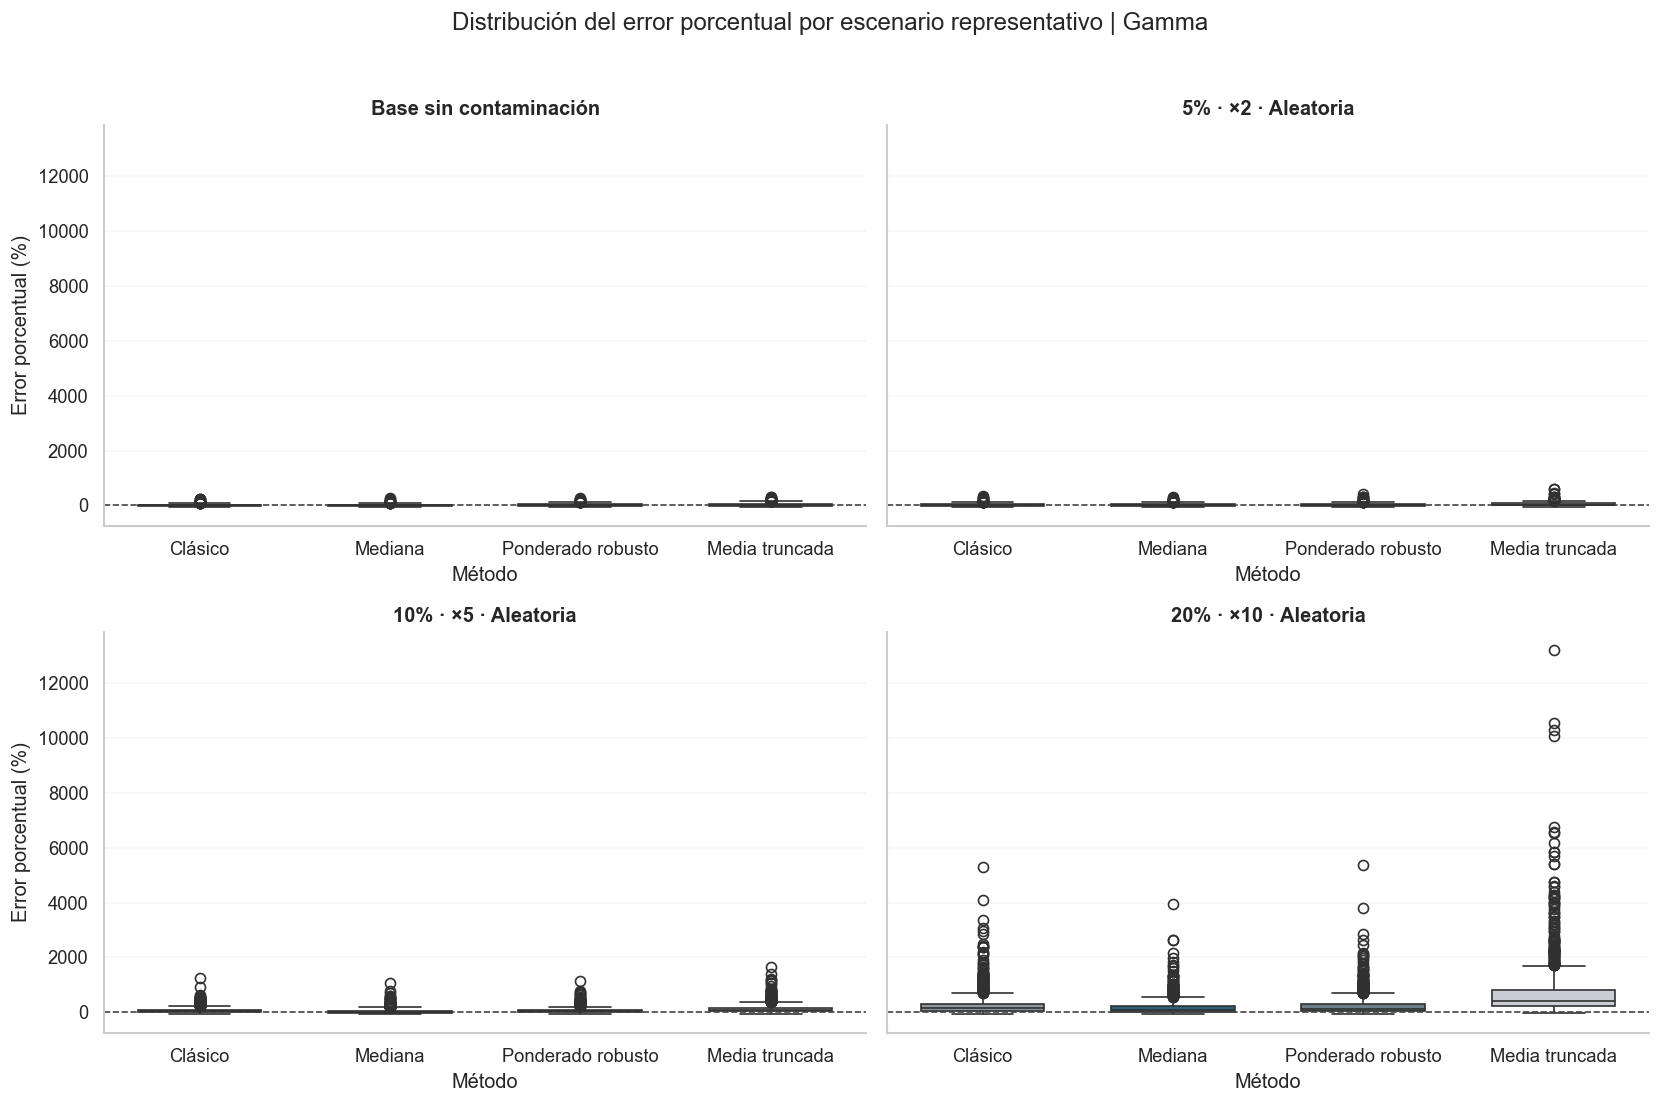

In [18]:

# Boxplots de error porcentual para cuatro escenarios guía bajo Gamma
tabla_escenarios_representativos = pd.DataFrame(
    [
        {"Escenario": formatear_escenario(ESCENARIO_BASE), "Papel en la lectura": "Punto de referencia sin contaminación"},
        {"Escenario": formatear_escenario(ESCENARIO_CONTAMINACION_LEVE), "Papel en la lectura": "Contaminación leve para ver el costo de robustificar"},
        {"Escenario": formatear_escenario(ESCENARIO_CONTAMINACION_INTERMEDIA), "Papel en la lectura": "Zona de transición entre eficiencia y robustez"},
        {"Escenario": formatear_escenario(ESCENARIO_CONTAMINACION_MAXIMA), "Papel en la lectura": "Contaminación máxima para forzar el contraste entre métodos"},
    ]
)
display(tabla_escenarios_representativos)

graficar_boxplots_representativos(
    resultados_df,
    ESCENARIOS_REPRESENTATIVOS,
    titulo_general="Distribución del error porcentual por escenario representativo | Gamma",
    nombre_archivo="boxplots_gamma_escenarios_representativos.png",
)


En este gráfico, la línea horizontal en cero representa estimación sin error. Valores por encima de cero indican sobreestimación y valores por debajo de cero indican subestimación. La dispersión vertical de cada caja refleja estabilidad: cajas más altas o colas más largas indican mayor variabilidad del método. Esta visualización resulta más informativa que comparar niveles absolutos del IBNR, porque normaliza los errores respecto del tamaño real del IBNR en cada escenario.


## Resultados por familias de escenarios

Las tablas originales con nueve escenarios por familia eran difíciles de leer en bloque. Para la sustentación conviene una estructura más directa: una tabla resume el **RMSE** y otra resume la **desviación estándar**. En ambas se muestran dos lecturas complementarias: el método con mejor promedio dentro de la familia y el método que gana más escenarios individuales dentro de esa misma familia.


In [19]:

# Tablas limpias por familias: precisión y estabilidad bajo Gamma
resultados_familia_df = resumir_resultados_familia(metricas_df, clasificacion_df, etiquetas_metodos=ETIQUETAS_METODOS)

tabla_familias_rmse_gamma = construir_tabla_familias_metricas(
    metricas_df,
    metrica="rmse",
    etiqueta_valor="RMSE promedio",
)
tabla_familias_desviacion_gamma = construir_tabla_familias_metricas(
    metricas_df,
    metrica="desviacion_estandar_estimaciones",
    etiqueta_valor="Desviación estándar promedio",
)

print("Tabla resumen por familias según RMSE:")
display(tabla_familias_rmse_gamma)
print("Tabla resumen por familias según desviación estándar:")
display(tabla_familias_desviacion_gamma)


Tabla resumen por familias según RMSE:


,Familia,Método con mejor promedio,RMSE promedio,Método con más escenarios ganados,Frecuencia ganadora
0,Sin contaminación,Clásico,600.4200,Clásico,1/1
1,Contaminación del 5%,Mediana,"1,333.8500",Mediana,7/9
2,Contaminación del 10%,Mediana,"1,907.5600",Clásico,5/9
3,Contaminación del 20%,Mediana,"2,471.5400",Mediana,6/9
4,Outliers ×2,Mediana,765.2000,Clásico,7/9
5,Outliers ×5,Mediana,"1,668.7700",Mediana,7/9
6,Outliers ×10,Mediana,"3,278.9900",Mediana,8/9
7,Contaminación temprana,Mediana,"1,620.8500",Clásico,6/9
8,Contaminación tardía,Mediana,"1,933.6300",Mediana,6/9
9,Contaminación aleatoria,Mediana,"2,158.4700",Mediana,8/9


Tabla resumen por familias según desviación estándar:


,Familia,Método con mejor promedio,Desviación estándar promedio,Método con más escenarios ganados,Frecuencia ganadora
0,Sin contaminación,Clásico,540.0100,Clásico,1/1
1,Contaminación del 5%,Mediana,"1,262.4300",Mediana,5/9
2,Contaminación del 10%,Mediana,"1,775.7300",Clásico,5/9
3,Contaminación del 20%,Mediana,"2,163.9900",Mediana,6/9
4,Outliers ×2,Clásico,683.1700,Clásico,8/9
5,Outliers ×5,Mediana,"1,523.5000",Mediana,6/9
6,Outliers ×10,Mediana,"2,980.3600",Mediana,8/9
7,Contaminación temprana,Mediana,"1,526.8600",Clásico,6/9
8,Contaminación tardía,Mediana,"1,760.9000",Mediana,5/9
9,Contaminación aleatoria,Mediana,"1,914.3900",Mediana,7/9


La tabla anterior muestra tres patrones centrales. Primero, el escenario limpio favorece al método clásico, mientras que la familia de outliers de magnitud `×2` ya favorece a la mediana en RMSE promedio, aunque el clásico conserva más victorias por escenario. Segundo, las familias asociadas a contaminación del `20%`, así como las magnitudes `×5` y `×10`, favorecen con claridad a la mediana tanto en desempeño promedio como en número de victorias. Tercero, la contaminación del `10%` y la contaminación temprana se comportan como zonas de transición: la mediana obtiene el mejor RMSE promedio, pero el método clásico todavía conserva más victorias individuales dentro de esas familias.


## Justificación empírica del número de réplicas

La cantidad de réplicas se justifica con curvas de convergencia del RMSE acumulado. Se contrasta el escenario base con el método clásico frente al escenario más severo con la mediana. Si ambas trayectorias se estabilizan, la elección de 1000 réplicas en Gamma deja de ser una decisión arbitraria y pasa a ser una decisión empíricamente defendible.


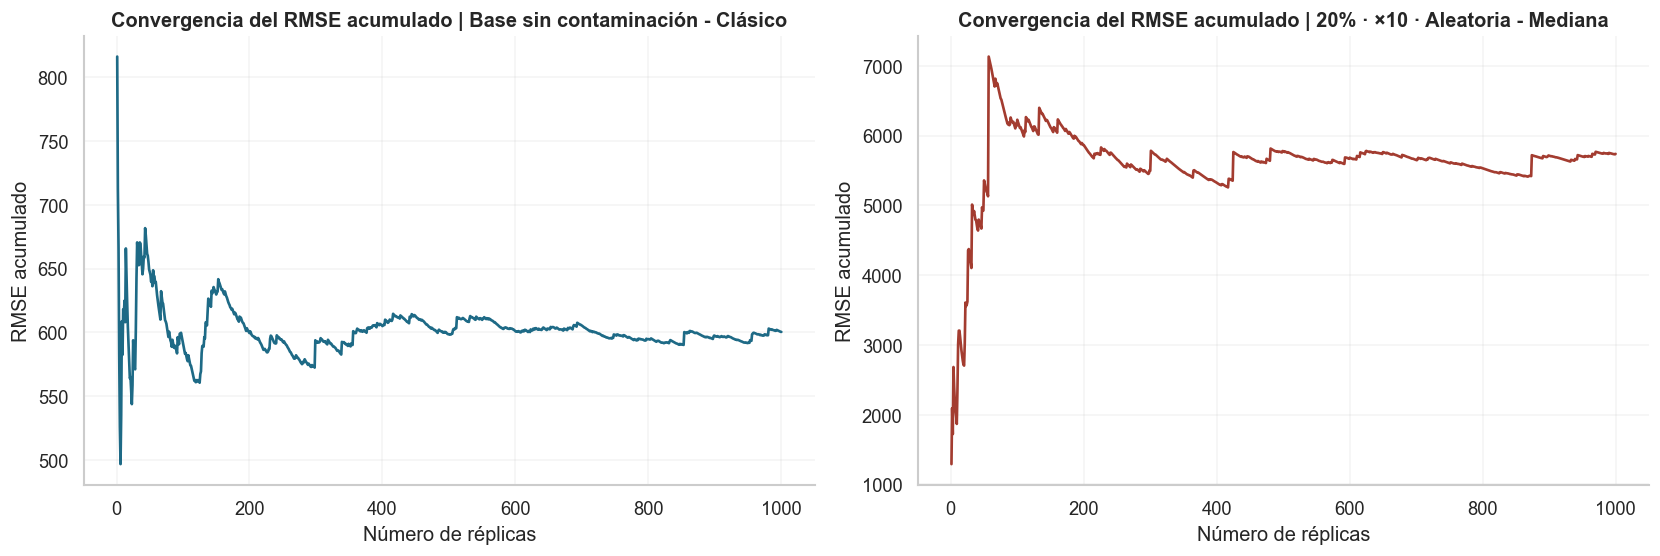

,Escenario,Método,RMSE final,Variación relativa desde la réplica 600 (%)
0,Base sin contaminación,Clásico,600.4200,2.8900
1,20% · ×10 · Aleatoria,Mediana,"5,738.2800",6.4300


In [20]:

# Convergencia del RMSE acumulado en el experimento Gamma
acumulado_base_gamma, acumulado_severo_gamma = graficar_convergencia_doble(
    resultados_df,
    escenario_referencia=ESCENARIO_BASE,
    metodo_referencia="clasico",
    escenario_contraste=ESCENARIO_CONTAMINACION_MAXIMA,
    metodo_contraste="mediana",
    nombre_archivo="convergencia_gamma_1000replicas.png",
)

tabla_convergencia_gamma = pd.DataFrame(
    [
        {
            "Escenario": formatear_escenario(ESCENARIO_BASE),
            "Método": ETIQUETAS_METODOS["clasico"],
            "RMSE final": round(float(acumulado_base_gamma["rmse_acumulado"].iloc[-1]), 2),
            "Variación relativa desde la réplica 600 (%)": round(resumir_estabilidad_final(acumulado_base_gamma, 600), 2),
        },
        {
            "Escenario": formatear_escenario(ESCENARIO_CONTAMINACION_MAXIMA),
            "Método": ETIQUETAS_METODOS["mediana"],
            "RMSE final": round(float(acumulado_severo_gamma["rmse_acumulado"].iloc[-1]), 2),
            "Variación relativa desde la réplica 600 (%)": round(resumir_estabilidad_final(acumulado_severo_gamma, 600), 2),
        },
    ]
)
display(tabla_convergencia_gamma)


## Evaluación de la hipótesis

La hipótesis del estudio se evalúa con cuatro fuentes de evidencia: el comportamiento del error del método clásico, la variabilidad relativa de las variantes robustas, la lectura por familias de escenarios y la comparación pareada frente al enfoque clásico.


In [21]:
# Evaluación sintética de la hipótesis con base en métricas observadas
tabla_correlacion, resumen_desviacion_robusta, tabla_hipotesis = evaluar_hipotesis_principal(
    metricas_df,
    resultados_familia_df,
    etiquetas_metodos=ETIQUETAS_METODOS,
)

print("Correlaciones de Spearman para el método clásico en escenarios contaminados:")
display(tabla_correlacion)
print("Resumen de estabilidad relativa de los métodos robustos:")
display(resumen_desviacion_robusta.loc[:, [
    "etiqueta_metodo_robusto",
    "escenarios_con_menor_sd_que_clasico",
    "total_escenarios_contaminados",
    "proporcion_favorable",
]])
print("Evaluación sintética de la hipótesis:")
display(tabla_hipotesis)

Correlaciones de Spearman para el método clásico en escenarios contaminados:


,proporcion_contaminacion,magnitud_contaminacion,log_magnitud,rmse,mape,desviacion_estandar_estimaciones
proporcion_contaminacion,1.0000,0.0000,0.0000,0.3436,0.4193,0.3378
magnitud_contaminacion,0.0000,1.0000,1.0000,0.9027,0.8445,0.9143
log_magnitud,0.0000,1.0000,1.0000,0.9027,0.8445,0.9143
rmse,0.3436,0.9027,0.9027,1.0000,0.9884,0.9969
mape,0.4193,0.8445,0.8445,0.9884,1.0000,0.9811
desviacion_estandar_estimaciones,0.3378,0.9143,0.9143,0.9969,0.9811,1.0000


Resumen de estabilidad relativa de los métodos robustos:


,etiqueta_metodo_robusto,escenarios_con_menor_sd_que_clasico,total_escenarios_contaminados,proporcion_favorable
0,Mediana,15,27,0.5556
1,Media truncada,0,27,0.0000
2,Ponderado robusto,7,27,0.2593


Evaluación sintética de la hipótesis:


,hipotesis,evidencia_principal,dictamen
0,H1,"Correlacion de Spearman del RMSE clasico con proporcion = 0.344, con magnitud = 0.903. En la lectura por familias, Mediana lidera 9 de 9...",Apoyada


In [22]:
# Síntesis de hallazgos principales del experimento Gamma
ganador_limpio = mejor_por_escenario.loc[mejor_por_escenario["escenario"] == "base_sin_contaminacion", "metodo"].iloc[0]
victorias_contaminadas = (
    mejor_por_escenario.query("escenario != 'base_sin_contaminacion'")
    .groupby("metodo")
    .size()
    .to_dict()
)
mayores_ventajas_mediana = (
    comparaciones_df.query("metodo == 'mediana'")
    .sort_values("delta_mse_promedio")
    .loc[:, ["escenario", "delta_mse_promedio", "delta_mape_promedio",
             "proporcion_contaminacion", "magnitud_contaminacion", "ubicacion_contaminacion"]]
    .head(5)
)

tabla_resultados_clave = pd.DataFrame(
    [
        {"hallazgo": "Método ganador en el escenario base", "resultado": ganador_limpio},
        {
            "hallazgo": "Escenarios contaminados ganados por la mediana",
            "resultado": victorias_contaminadas.get("mediana", 0),
        },
        {
            "hallazgo": "Escenarios contaminados ganados por el método clásico",
            "resultado": victorias_contaminadas.get("clasico", 0),
        },
        {
            "hallazgo": "Método con menor RMSE promedio global",
            "resultado": resumen_global.iloc[0]["metodo"],
        },
    ]
)

print("Hallazgos principales del experimento Gamma:")
display(tabla_resultados_clave)
print("Escenarios con mayor ventaja de la mediana frente al método clásico:")
display(mayores_ventajas_mediana)

Hallazgos principales del experimento Gamma:


,hallazgo,resultado
0,Método ganador en el escenario base,clasico
1,Escenarios contaminados ganados por la mediana,17
2,Escenarios contaminados ganados por el método clásico,10
3,Método con menor RMSE promedio global,mediana


Escenarios con mayor ventaja de la mediana frente al método clásico:


,escenario,delta_mse_promedio,delta_mape_promedio,proporcion_contaminacion,magnitud_contaminacion,ubicacion_contaminacion
30,p20_m10_aleatoria,"-42,121,284.7561",-0.9023,0.2000,10.0000,aleatoria
33,p20_m10_tardia,"-25,133,347.7399",-1.0460,0.2000,10.0000,tardia
3,p10_m10_aleatoria,"-13,848,849.8082",-0.6142,0.1000,10.0000,aleatoria
6,p10_m10_tardia,"-5,049,068.4458",-0.3223,0.1000,10.0000,tardia
57,p5_m10_aleatoria,"-4,597,028.9087",-0.3147,0.0500,10.0000,aleatoria


La evidencia obtenida muestra un patrón consistente. En datos limpios, el método clásico conserva ventajas de eficiencia. Sin embargo, conforme aumentan la magnitud y la frecuencia de la contaminación, la mediana se convierte en la opción más estable y precisa. La tabla por familias añade un matiz importante: la contaminación del `10%`, los outliers de magnitud `×2` y la contaminación temprana funcionan como zonas de transición, porque la mediana mejora el RMSE promedio, pero el método clásico aún retiene varias victorias por escenario. En esta implementación, la media truncada no confirma la ventaja esperada y la versión ponderada no domina de forma sistemática.


## Sensibilidad a colas más pesadas

Como contraste del experimento principal, se repite la simulación con distribución Lognormal. Esta extensión permite verificar si el orden relativo entre métodos cambia cuando el proceso generador presenta colas más pesadas. Para no duplicar el costo computacional del experimento Gamma, se trabaja con **400 réplicas**, pero esa elección también se justifica con una curva de convergencia propia.


In [23]:

# Experimento complementario con distribución Lognormal
NUMERO_REPLICAS_LOGNORMAL = 400
configuracion_lognormal = clonar_configuracion(configuracion, distribucion="lognormal", semilla_aleatoria=SEMILLA)
resultados_lognormal = ejecutar_experimento(configuracion_lognormal, escenarios, n_replicas=NUMERO_REPLICAS_LOGNORMAL)

# Se replican las mismas columnas auxiliares para mantener la trazabilidad entre distribuciones.
resultados_lognormal["error"] = resultados_lognormal["ibnr_estimado"] - resultados_lognormal["ibnr_real"]
resultados_lognormal["error_absoluto"] = np.abs(resultados_lognormal["error"])
resultados_lognormal["error_porcentual"] = resultados_lognormal["error"] / resultados_lognormal["ibnr_real"]
resultados_lognormal["error_porcentual_absoluto"] = np.abs(resultados_lognormal["error_porcentual"])

metricas_lognormal = calcular_metricas_metodos(resultados_lognormal)
clasificacion_lognormal = clasificar_metodos_en_escenario(metricas_lognormal, metrica="rmse")
resumen_global_lognormal = construir_resumen_global(metricas_lognormal)
dominancia_lognormal = resumir_dominancia_metodos(clasificacion_lognormal)
resultados_familia_lognormal = resumir_resultados_familia(metricas_lognormal, clasificacion_lognormal, etiquetas_metodos=ETIQUETAS_METODOS)
tabla_familias_rmse_lognormal = construir_tabla_familias_metricas(metricas_lognormal, "rmse", "RMSE promedio")
tabla_familias_desviacion_lognormal = construir_tabla_familias_metricas(metricas_lognormal, "desviacion_estandar_estimaciones", "Desviación estándar promedio")

print("Resumen global bajo Lognormal:")
display(resumen_global_lognormal)
print("Dominancia por escenarios bajo Lognormal:")
display(dominancia_lognormal)


Resumen global bajo Lognormal:


,metodo,rmse_promedio,mape_promedio,sesgo_absoluto_promedio,desviacion_estandar_promedio
0,mediana,"1,722.5790",0.5825,599.6843,"1,565.7014"
1,ponderado,"1,949.3421",0.6729,828.2139,"1,720.5509"
2,clasico,"2,179.2352",0.7542,916.2248,"1,915.9988"
3,truncada,"3,420.0319",1.2476,"1,887.3369","2,815.9251"


Dominancia por escenarios bajo Lognormal:


,metodo,escenarios_ganados
0,mediana,24
1,clasico,4



### Panorama de error y estabilidad bajo Lognormal

Para que la comparación entre distribuciones sea homogénea, se replican exactamente las dos visualizaciones centrales del experimento Gamma: RMSE promedio por método con mapa de calor por escenario, y desviación estándar promedio con su respectivo mapa de calor. Así se puede ver si la jerarquía entre métodos se mantiene cuando la cola de la distribución es más pesada.


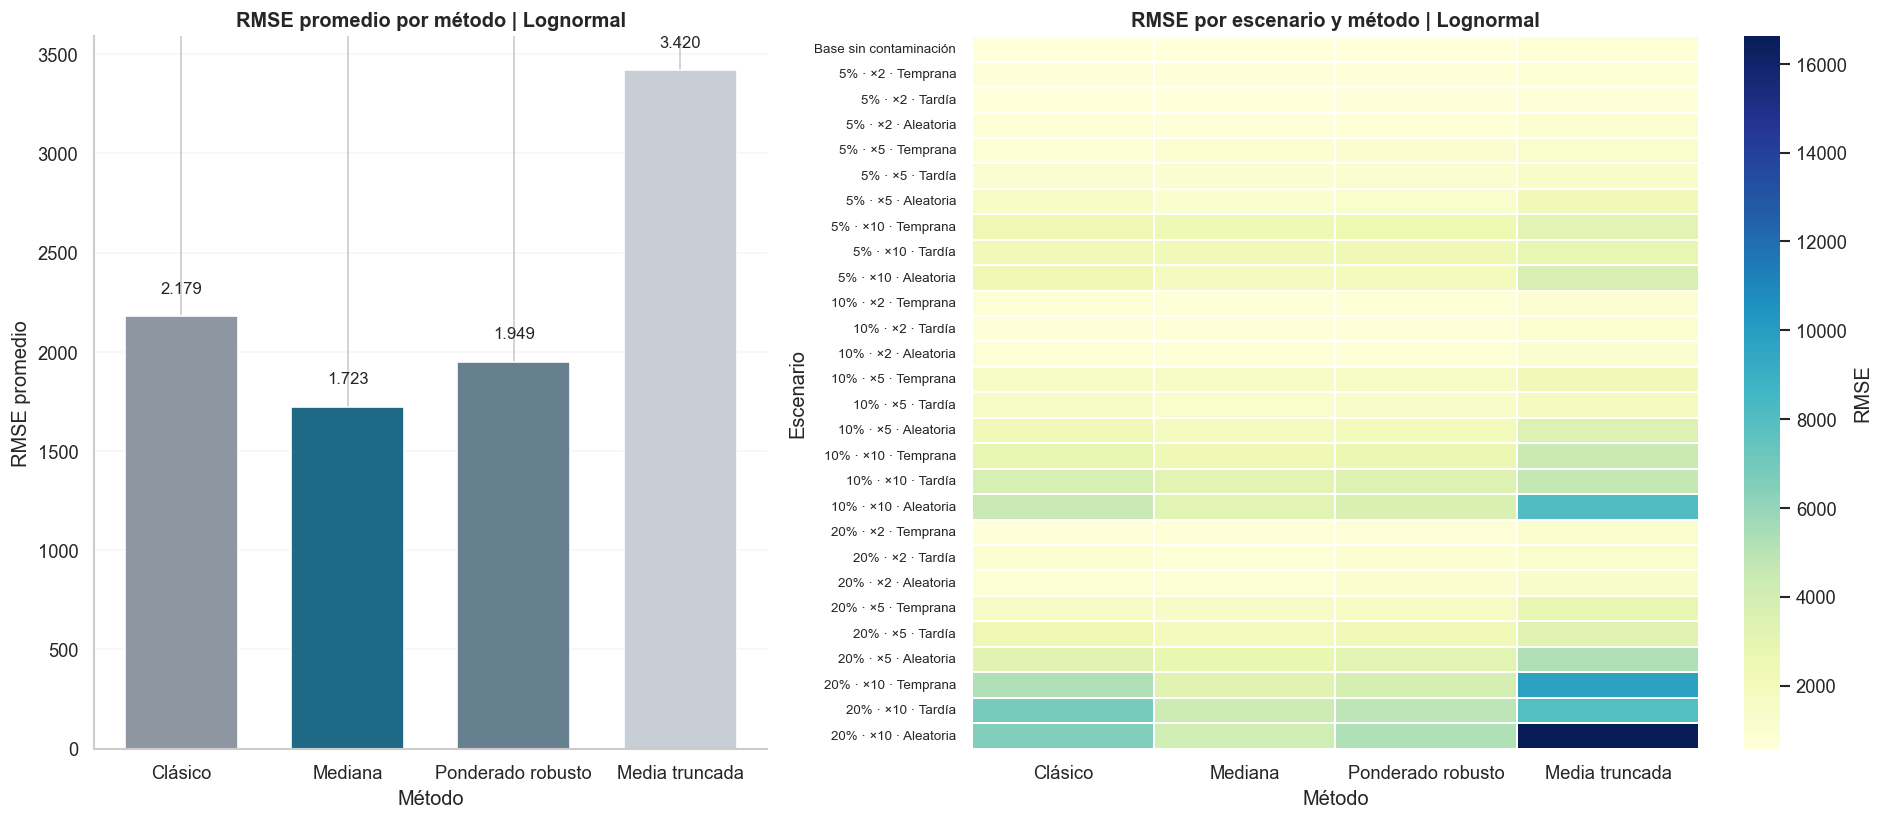

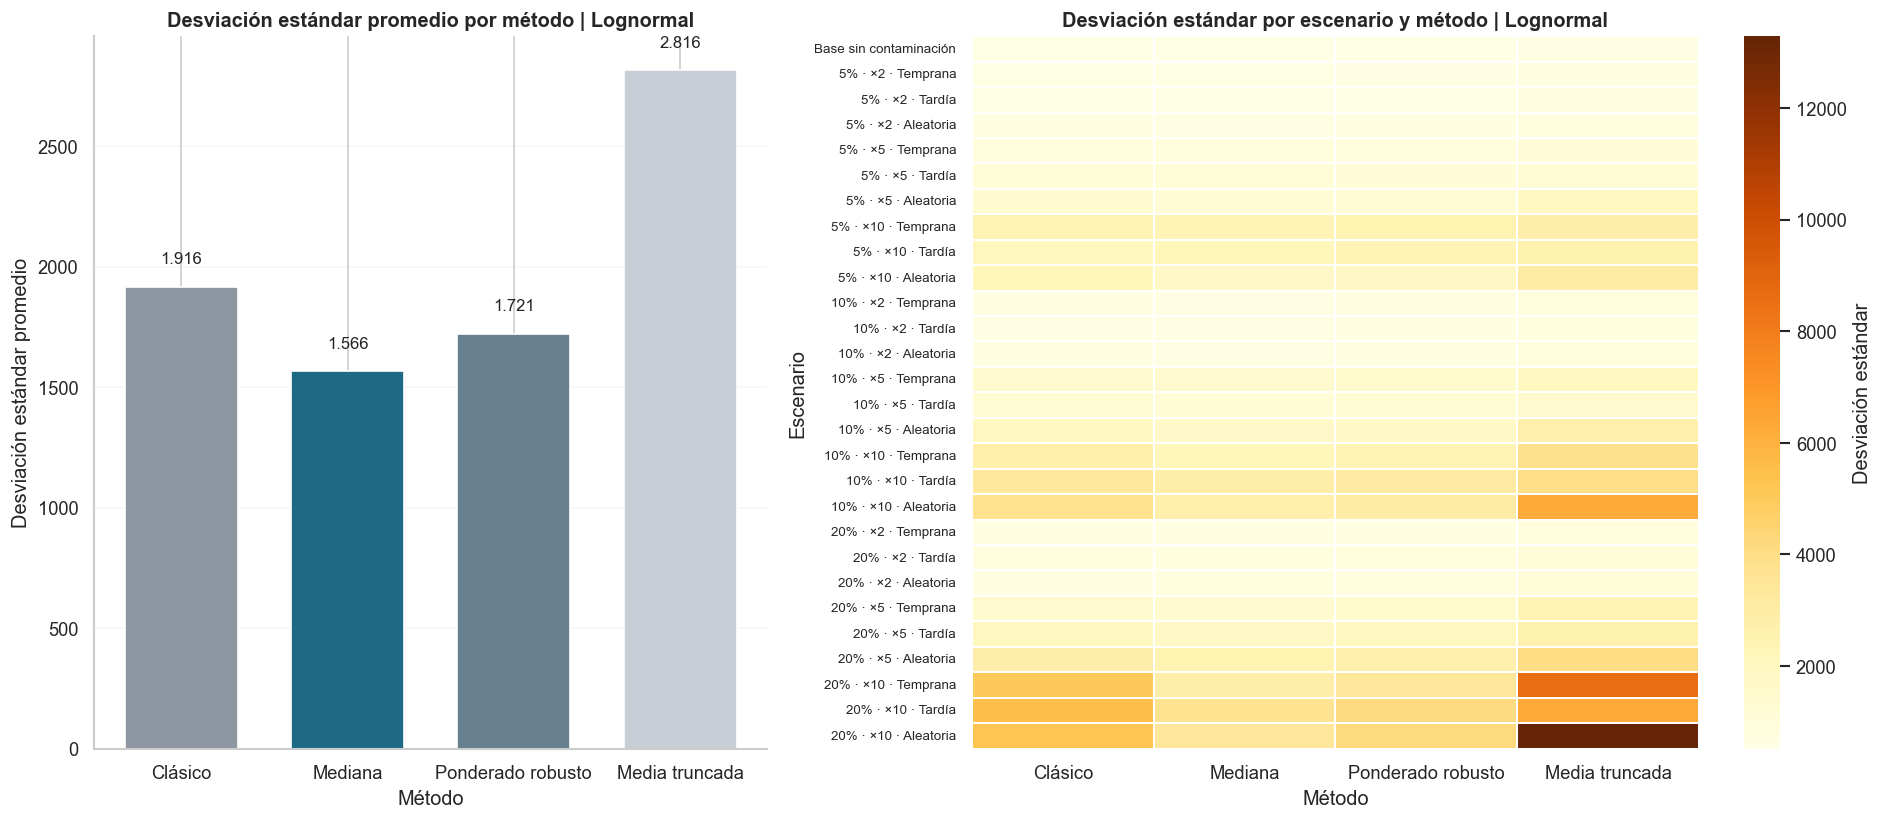

In [24]:

# Visualizaciones principales de RMSE y desviación estándar bajo Lognormal
resumen_rmse_lognormal = graficar_barra_y_mapa_calor(
    metricas_lognormal,
    metrica="rmse",
    titulo_barra="RMSE promedio por método | Lognormal",
    titulo_mapa="RMSE por escenario y método | Lognormal",
    etiqueta_eje_y="RMSE promedio",
    etiqueta_barra_color="RMSE",
    nombre_archivo="rmse_lognormal_barra_mapa.png",
    cmap="YlGnBu",
)

resumen_desviacion_lognormal = graficar_barra_y_mapa_calor(
    metricas_lognormal,
    metrica="desviacion_estandar_estimaciones",
    titulo_barra="Desviación estándar promedio por método | Lognormal",
    titulo_mapa="Desviación estándar por escenario y método | Lognormal",
    etiqueta_eje_y="Desviación estándar promedio",
    etiqueta_barra_color="Desviación estándar",
    nombre_archivo="desviacion_lognormal_barra_mapa.png",
    cmap="YlOrBr",
)



### Convergencia de Monte Carlo bajo Lognormal

Dado que esta sensibilidad usa 400 réplicas en lugar de 1000, conviene verificar si esa reducción sigue siendo suficiente. Se repite el mismo contraste del experimento principal: escenario base con el método clásico y escenario de contaminación máxima con la mediana.


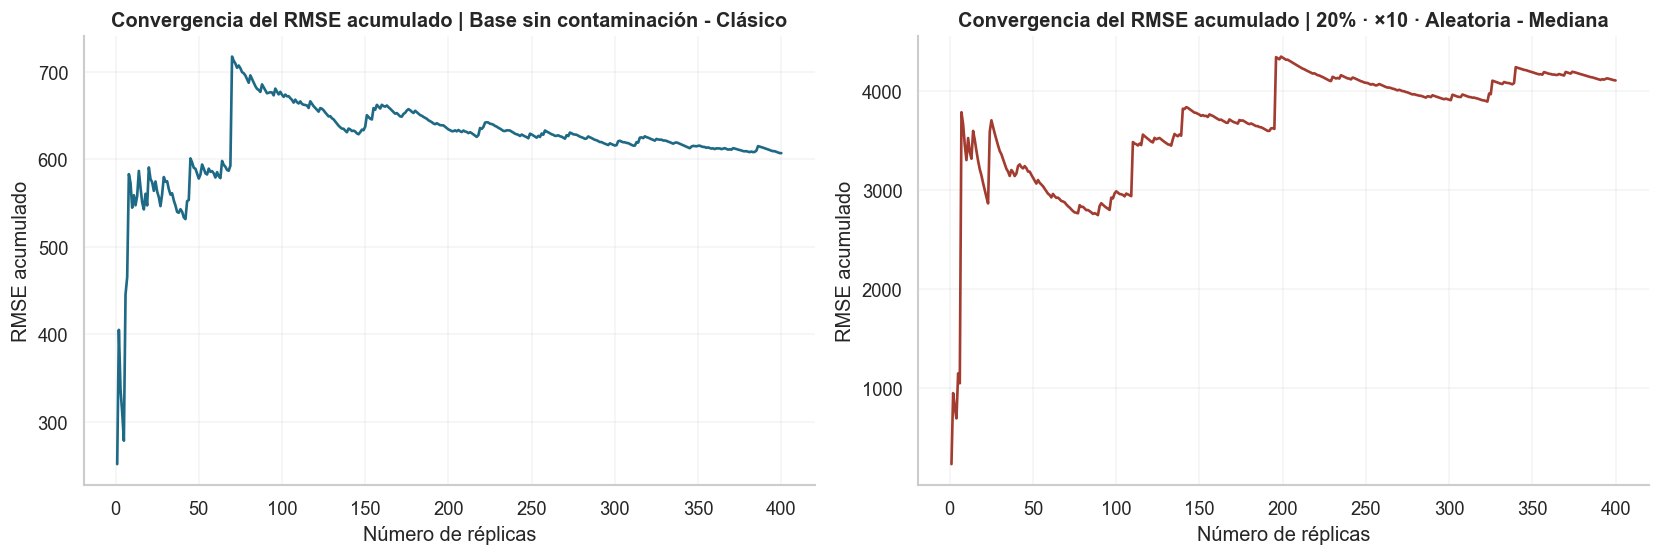

,Escenario,Método,RMSE final,Variación relativa desde la réplica 200 (%)
0,Base sin contaminación,Clásico,607.2100,5.8200
1,20% · ×10 · Aleatoria,Mediana,"4,105.0700",10.8000


In [25]:

# Convergencia del RMSE acumulado en el experimento Lognormal
acumulado_base_lognormal, acumulado_severo_lognormal = graficar_convergencia_doble(
    resultados_lognormal,
    escenario_referencia=ESCENARIO_BASE,
    metodo_referencia="clasico",
    escenario_contraste=ESCENARIO_CONTAMINACION_MAXIMA,
    metodo_contraste="mediana",
    nombre_archivo="convergencia_lognormal_400replicas.png",
)

tabla_convergencia_lognormal = pd.DataFrame(
    [
        {
            "Escenario": formatear_escenario(ESCENARIO_BASE),
            "Método": ETIQUETAS_METODOS["clasico"],
            "RMSE final": round(float(acumulado_base_lognormal["rmse_acumulado"].iloc[-1]), 2),
            "Variación relativa desde la réplica 200 (%)": round(resumir_estabilidad_final(acumulado_base_lognormal, 200), 2),
        },
        {
            "Escenario": formatear_escenario(ESCENARIO_CONTAMINACION_MAXIMA),
            "Método": ETIQUETAS_METODOS["mediana"],
            "RMSE final": round(float(acumulado_severo_lognormal["rmse_acumulado"].iloc[-1]), 2),
            "Variación relativa desde la réplica 200 (%)": round(resumir_estabilidad_final(acumulado_severo_lognormal, 200), 2),
        },
    ]
)
display(tabla_convergencia_lognormal)



### Distribución del error porcentual en escenarios representativos bajo Lognormal

La misma selección de cuatro escenarios se conserva en la sensibilidad Lognormal para que la comparación visual sea directa. Si la mediana mantiene cajas más compactas y más cercanas a cero incluso con colas más pesadas, el argumento a favor de la robustez se vuelve más convincente.


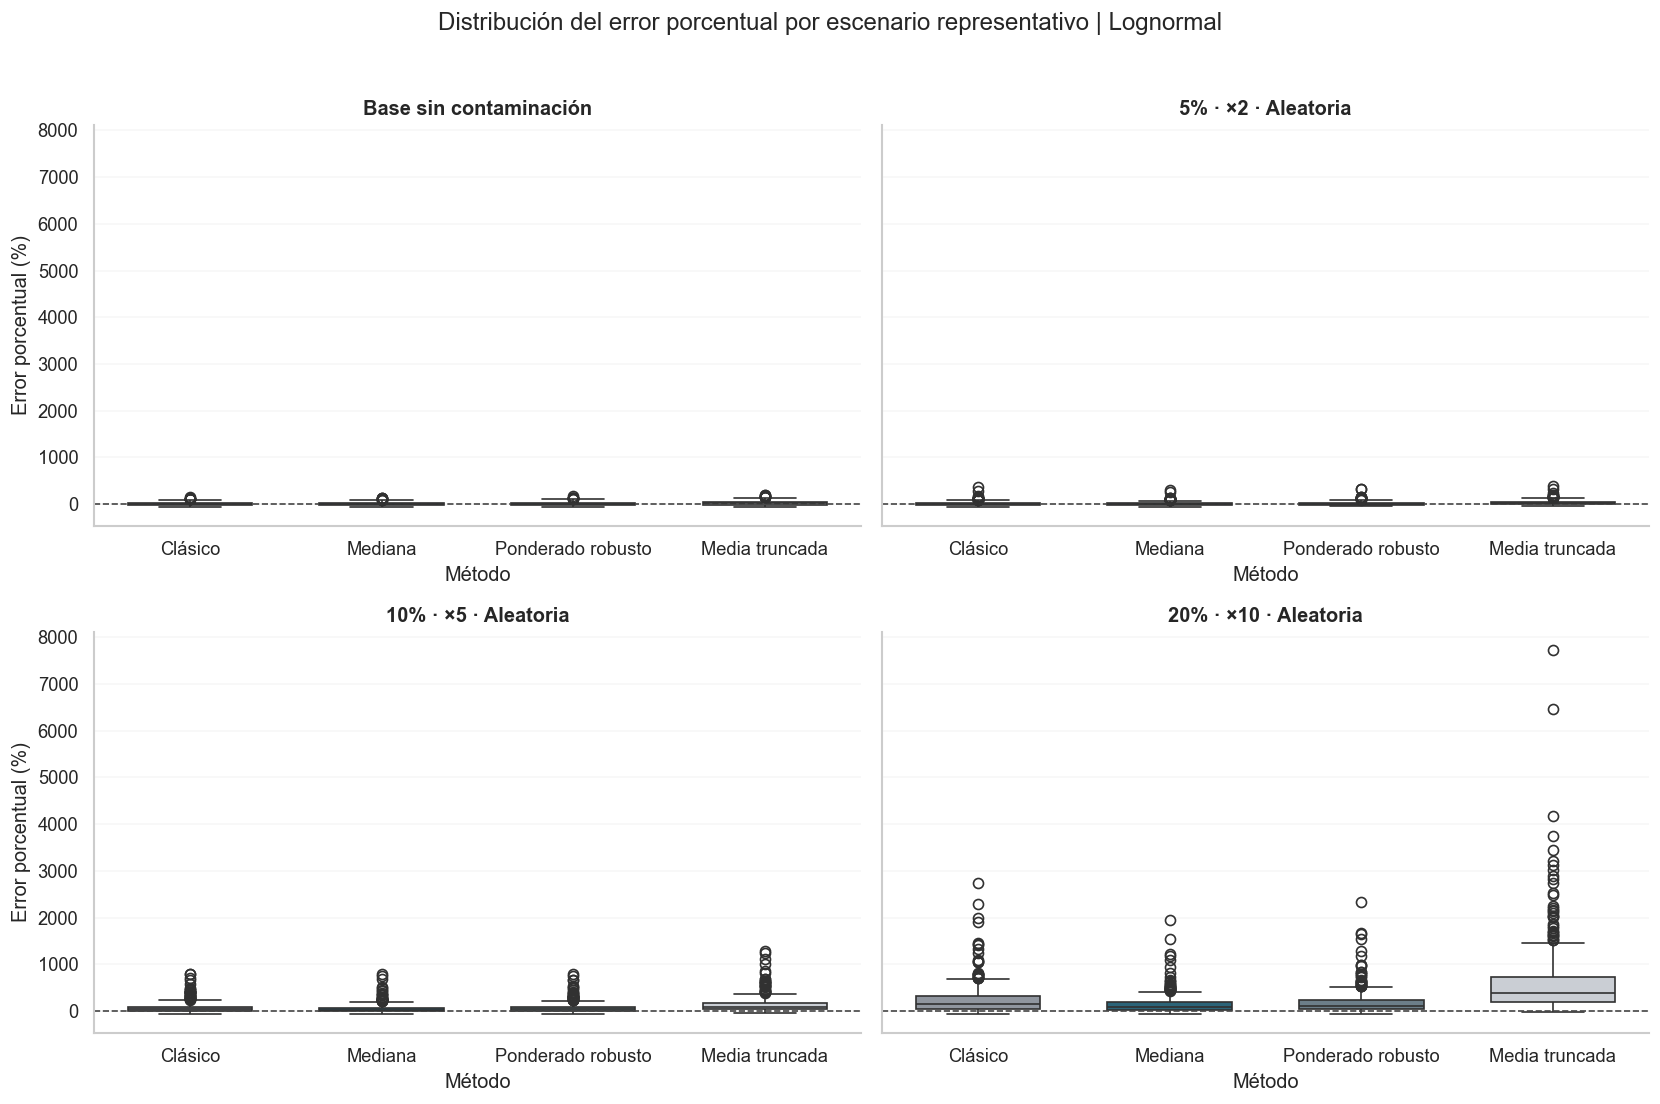

In [26]:

# Boxplots de error porcentual para los mismos cuatro escenarios bajo Lognormal
graficar_boxplots_representativos(
    resultados_lognormal,
    ESCENARIOS_REPRESENTATIVOS,
    titulo_general="Distribución del error porcentual por escenario representativo | Lognormal",
    nombre_archivo="boxplots_lognormal_escenarios_representativos.png",
)


In [27]:

# Comparación resumida entre resultados Gamma y Lognormal
gamma_vs_lognormal = (
    resumen_global.loc[:, ["metodo", "rmse_promedio", "mape_promedio"]]
    .rename(columns={"rmse_promedio": "rmse_promedio_gamma", "mape_promedio": "mape_promedio_gamma"})
    .merge(
        resumen_global_lognormal.loc[:, ["metodo", "rmse_promedio", "mape_promedio"]]
        .rename(columns={"rmse_promedio": "rmse_promedio_lognormal", "mape_promedio": "mape_promedio_lognormal"}),
        on="metodo",
        how="inner",
    )
    .sort_values("rmse_promedio_gamma")
    .reset_index(drop=True)
)
gamma_vs_lognormal


,metodo,rmse_promedio_gamma,mape_promedio_gamma,rmse_promedio_lognormal,mape_promedio_lognormal
0,mediana,"1,858.7110",0.6241,"1,722.5790",0.5825
1,ponderado,"2,166.3624",0.7316,"1,949.3421",0.6729
2,clasico,"2,229.1016",0.7727,"2,179.2352",0.7542
3,truncada,"3,944.8316",1.3993,"3,420.0319",1.2476



La sensibilidad Lognormal no cambia el mensaje principal del experimento: la **mediana** sigue ocupando el primer lugar tanto en precisión como en estabilidad promedio. Esto es valioso porque la Lognormal impone colas más pesadas y, por lo tanto, un entorno más exigente para el control del error. Que la jerarquía se mantenga indica que el hallazgo no depende de una sola distribución generadora.



## Resultados consolidados para presentación y sustentación

Las siguientes tablas leen directamente los archivos exportados en `resultados/` y resumen la información que luego alimenta las diapositivas. La idea es que el cuaderno deje explícito el origen de las cifras: resúmenes globales, tablas por familias y lista de escenarios donde el método clásico todavía supera a la mediana.


In [28]:

# Carga consolidada de resultados finales exportados
# Primero se escriben los resultados actuales del cuaderno y luego se vuelven a leer
# para que la trazabilidad hacia la presentación quede completamente explícita.
resumen_global.to_csv(DIRECTORIO_RESULTADOS / "resumen_global_gamma_1000replicas.csv", index=False)
resumen_global_lognormal.to_csv(DIRECTORIO_RESULTADOS / "resumen_global_lognormal_400replicas.csv", index=False)
resultados_familia_df.to_csv(DIRECTORIO_RESULTADOS / "resultados_familia_gamma_1000replicas.csv", index=False)
resultados_familia_lognormal.to_csv(DIRECTORIO_RESULTADOS / "resultados_familia_lognormal_400replicas.csv", index=False)
resumen_desviacion_robusta.to_csv(DIRECTORIO_RESULTADOS / "resumen_desviacion_robusta_gamma_1000replicas.csv", index=False)
clasificacion_df.to_csv(DIRECTORIO_RESULTADOS / "clasificacion_gamma_1000replicas.csv", index=False)
clasificacion_lognormal.to_csv(DIRECTORIO_RESULTADOS / "clasificacion_lognormal_400replicas.csv", index=False)
metricas_df.to_csv(DIRECTORIO_RESULTADOS / "metricas_gamma_1000replicas.csv", index=False)
metricas_lognormal.to_csv(DIRECTORIO_RESULTADOS / "metricas_lognormal_400replicas.csv", index=False)
tabla_familias_rmse_gamma.to_csv(DIRECTORIO_RESULTADOS / "tabla_familias_rmse_gamma_1000replicas.csv", index=False)
tabla_familias_desviacion_gamma.to_csv(DIRECTORIO_RESULTADOS / "tabla_familias_desviacion_gamma_1000replicas.csv", index=False)
tabla_familias_rmse_lognormal.to_csv(DIRECTORIO_RESULTADOS / "tabla_familias_rmse_lognormal_400replicas.csv", index=False)
tabla_familias_desviacion_lognormal.to_csv(DIRECTORIO_RESULTADOS / "tabla_familias_desviacion_lognormal_400replicas.csv", index=False)

resumen_global_gamma_presentacion = pd.read_csv(DIRECTORIO_RESULTADOS / "resumen_global_gamma_1000replicas.csv")
resumen_global_lognormal_presentacion = pd.read_csv(DIRECTORIO_RESULTADOS / "resumen_global_lognormal_400replicas.csv")
tabla_familias_rmse_gamma_presentacion = pd.read_csv(DIRECTORIO_RESULTADOS / "tabla_familias_rmse_gamma_1000replicas.csv")
tabla_familias_desviacion_gamma_presentacion = pd.read_csv(DIRECTORIO_RESULTADOS / "tabla_familias_desviacion_gamma_1000replicas.csv")
tabla_familias_rmse_lognormal_presentacion = pd.read_csv(DIRECTORIO_RESULTADOS / "tabla_familias_rmse_lognormal_400replicas.csv")
tabla_familias_desviacion_lognormal_presentacion = pd.read_csv(DIRECTORIO_RESULTADOS / "tabla_familias_desviacion_lognormal_400replicas.csv")
clasificacion_gamma_presentacion = pd.read_csv(DIRECTORIO_RESULTADOS / "clasificacion_gamma_1000replicas.csv")

ganadores_gamma_presentacion = clasificacion_gamma_presentacion.query("rango == 1").copy()
escenarios_clasico_contaminados = (
    ganadores_gamma_presentacion.query("metodo == 'clasico' and escenario != 'base_sin_contaminacion'")
    .loc[:, [
        "escenario",
        "rmse",
        "proporcion_contaminacion",
        "magnitud_contaminacion",
        "ubicacion_contaminacion",
    ]]
    .assign(Escenario=lambda df: df["escenario"].map(formatear_escenario))
    .loc[:, ["Escenario", "rmse", "proporcion_contaminacion", "magnitud_contaminacion", "ubicacion_contaminacion"]]
    .rename(columns={
        "rmse": "RMSE del clásico",
        "proporcion_contaminacion": "Proporción",
        "magnitud_contaminacion": "Magnitud",
        "ubicacion_contaminacion": "Ubicación",
    })
    .sort_values(["Proporción", "Magnitud", "Ubicación", "Escenario"])
    .reset_index(drop=True)
)

escenarios_mediana_contaminados = (
    ganadores_gamma_presentacion.query("metodo == 'mediana' and escenario != 'base_sin_contaminacion'")
    .loc[:, [
        "escenario",
        "rmse",
        "proporcion_contaminacion",
        "magnitud_contaminacion",
        "ubicacion_contaminacion",
    ]]
    .assign(Escenario=lambda df: df["escenario"].map(formatear_escenario))
    .loc[:, ["Escenario", "rmse", "proporcion_contaminacion", "magnitud_contaminacion", "ubicacion_contaminacion"]]
    .rename(columns={
        "rmse": "RMSE de la mediana",
        "proporcion_contaminacion": "Proporción",
        "magnitud_contaminacion": "Magnitud",
        "ubicacion_contaminacion": "Ubicación",
    })
    .sort_values(["Proporción", "Magnitud", "Ubicación", "Escenario"])
    .reset_index(drop=True)
)


In [29]:

# Tablas finales para presentación y sustentación
print("Resumen global del experimento principal (Gamma):")
display(resumen_global_gamma_presentacion)

print("Resumen global de la sensibilidad Lognormal:")
display(resumen_global_lognormal_presentacion)

print("Tabla limpia por familias según RMSE (Gamma):")
display(tabla_familias_rmse_gamma_presentacion)

print("Tabla limpia por familias según desviación estándar (Gamma):")
display(tabla_familias_desviacion_gamma_presentacion)

print("Escenarios contaminados donde el método clásico todavía supera a la mediana:")
display(escenarios_clasico_contaminados)


Resumen global del experimento principal (Gamma):


,metodo,rmse_promedio,mape_promedio,sesgo_absoluto_promedio,desviacion_estandar_promedio
0,mediana,"1,858.7110",0.6241,649.0613,"1,692.4732"
1,ponderado,"2,166.3624",0.7316,911.8454,"1,921.9900"
2,clasico,"2,229.1016",0.7727,927.5342,"1,968.0474"
3,truncada,"3,944.8316",1.3993,"2,128.0778","3,288.3559"


Resumen global de la sensibilidad Lognormal:


,metodo,rmse_promedio,mape_promedio,sesgo_absoluto_promedio,desviacion_estandar_promedio
0,mediana,"1,722.5790",0.5825,599.6843,"1,565.7014"
1,ponderado,"1,949.3421",0.6729,828.2139,"1,720.5509"
2,clasico,"2,179.2352",0.7542,916.2248,"1,915.9988"
3,truncada,"3,420.0319",1.2476,"1,887.3369","2,815.9251"


Tabla limpia por familias según RMSE (Gamma):


,Familia,Método con mejor promedio,RMSE promedio,Método con más escenarios ganados,Frecuencia ganadora
0,Sin contaminación,Clásico,600.4200,Clásico,1/1
1,Contaminación del 5%,Mediana,"1,333.8500",Mediana,7/9
2,Contaminación del 10%,Mediana,"1,907.5600",Clásico,5/9
3,Contaminación del 20%,Mediana,"2,471.5400",Mediana,6/9
4,Outliers ×2,Mediana,765.2000,Clásico,7/9
5,Outliers ×5,Mediana,"1,668.7700",Mediana,7/9
6,Outliers ×10,Mediana,"3,278.9900",Mediana,8/9
7,Contaminación temprana,Mediana,"1,620.8500",Clásico,6/9
8,Contaminación tardía,Mediana,"1,933.6300",Mediana,6/9
9,Contaminación aleatoria,Mediana,"2,158.4700",Mediana,8/9


Tabla limpia por familias según desviación estándar (Gamma):


,Familia,Método con mejor promedio,Desviación estándar promedio,Método con más escenarios ganados,Frecuencia ganadora
0,Sin contaminación,Clásico,540.0100,Clásico,1/1
1,Contaminación del 5%,Mediana,"1,262.4300",Mediana,5/9
2,Contaminación del 10%,Mediana,"1,775.7300",Clásico,5/9
3,Contaminación del 20%,Mediana,"2,163.9900",Mediana,6/9
4,Outliers ×2,Clásico,683.1700,Clásico,8/9
5,Outliers ×5,Mediana,"1,523.5000",Mediana,6/9
6,Outliers ×10,Mediana,"2,980.3600",Mediana,8/9
7,Contaminación temprana,Mediana,"1,526.8600",Clásico,6/9
8,Contaminación tardía,Mediana,"1,760.9000",Mediana,5/9
9,Contaminación aleatoria,Mediana,"1,914.3900",Mediana,7/9


Escenarios contaminados donde el método clásico todavía supera a la mediana:


,Escenario,RMSE del clásico,Proporción,Magnitud,Ubicación
0,5% · ×2 · Tardía,662.4432,0.0500,2.0000,tardia
1,5% · ×2 · Temprana,636.7036,0.0500,2.0000,temprana
2,10% · ×2 · Aleatoria,768.9754,0.1000,2.0000,aleatoria
3,10% · ×2 · Tardía,712.0646,0.1000,2.0000,tardia
4,10% · ×2 · Temprana,719.8015,0.1000,2.0000,temprana
5,10% · ×5 · Temprana,"1,648.7017",0.1000,5.0000,temprana
6,10% · ×10 · Temprana,"2,435.2005",0.1000,10.0000,temprana
7,20% · ×2 · Tardía,889.6183,0.2000,2.0000,tardia
8,20% · ×2 · Temprana,800.9801,0.2000,2.0000,temprana
9,20% · ×5 · Temprana,"1,895.2662",0.2000,5.0000,temprana



Las tablas finales dejan visible la frontera más útil para la sustentación. El método clásico conserva ventaja en el escenario limpio y todavía gana algunos escenarios contaminados, sobre todo cuando la contaminación es temprana o de magnitud baja. La mediana, por su parte, domina el RMSE promedio en todas las familias contaminadas y mantiene la ventaja cuando se pasa al contraste Lognormal.


## Conclusiones del experimento


El conjunto de resultados permite extraer cinco conclusiones principales:

1. **El método clásico conserva ventaja en el escenario limpio.** Esto es consistente con la idea de que la robustificación puede implicar un costo cuando la contaminación es inexistente.
2. **La mediana pasa a dominar el desempeño promedio cuando la contaminación deja de ser leve.** En particular, lidera todas las familias contaminadas según RMSE promedio, incluidas `×2`, `×5` y `×10`.
3. **La frontera entre eficiencia y robustez no es abrupta.** En la contaminación del `10%`, en los outliers `×2` y en la contaminación temprana, la mediana mejora el RMSE promedio, pero el método clásico todavía conserva más victorias por escenario.
4. **La media truncada y el método ponderado no dominan de forma general.** La media truncada no confirma la ventaja esperada bajo la parametrización utilizada, mientras que el método ponderado mejora en algunos contextos, pero no alcanza una ventaja sistemática.
5. **La conclusión principal es estable bajo la sensibilidad Lognormal.** El patrón general observado con Gamma no desaparece al introducir colas más pesadas, lo que fortalece la interpretación sustantiva del experimento.

En términos de la pregunta de investigación, la evidencia sugiere que las variantes robustas sí pueden superar al Chain-Ladder clásico, pero esa mejora depende del tipo de contaminación. El cambio más claro aparece cuando los outliers son suficientemente grandes, frecuentes o están ubicados en zonas que distorsionan con más fuerza los factores de desarrollo.

In [30]:

# Exportación de tablas finales para anexos o presentación
mapa_exportacion = {
    "diseno_escenarios.csv": diseno_escenarios_df,
    "metricas_gamma_1000replicas.csv": metricas_df,
    "metricas_lognormal_400replicas.csv": metricas_lognormal,
    "clasificacion_gamma_1000replicas.csv": clasificacion_df,
    "clasificacion_lognormal_400replicas.csv": clasificacion_lognormal,
    "comparaciones_con_clasico_gamma_1000replicas.csv": comparaciones_df,
    "resumen_comparaciones_gamma_1000replicas.csv": resumen_comparaciones,
    "resumen_global_gamma_1000replicas.csv": resumen_global,
    "resumen_global_lognormal_400replicas.csv": resumen_global_lognormal,
    "resumen_limpio_contaminado_gamma_1000replicas.csv": resumen_limpio_contaminado,
    "mejor_por_escenario_gamma_1000replicas.csv": mejor_por_escenario,
    "resultados_familia_gamma_1000replicas.csv": resultados_familia_df,
    "resultados_familia_lognormal_400replicas.csv": resultados_familia_lognormal,
    "tabla_familias_rmse_gamma_1000replicas.csv": tabla_familias_rmse_gamma,
    "tabla_familias_desviacion_gamma_1000replicas.csv": tabla_familias_desviacion_gamma,
    "tabla_familias_rmse_lognormal_400replicas.csv": tabla_familias_rmse_lognormal,
    "tabla_familias_desviacion_lognormal_400replicas.csv": tabla_familias_desviacion_lognormal,
    "estabilidad_familias_gamma_1000replicas.csv": tabla_familias_desviacion_gamma,
    "escenarios_ganados_por_clasico_gamma_1000replicas.csv": escenarios_clasico_contaminados,
    "escenarios_ganados_por_mediana_gamma_1000replicas.csv": escenarios_mediana_contaminados,
    "resultados_clave_gamma_1000replicas.csv": tabla_resultados_clave,
    "dominancia_metodos_gamma_1000replicas.csv": dominancia_df,
    "dominancia_metodos_lognormal_400replicas.csv": dominancia_lognormal,
    "evaluacion_hipotesis_gamma_1000replicas.csv": tabla_hipotesis,
    "resumen_gamma_vs_lognormal.csv": gamma_vs_lognormal,
    "resultados_crudos_gamma_1000replicas.csv": resultados_df,
    "resultados_crudos_lognormal_400replicas.csv": resultados_lognormal,
}

exportados = []
omitidos = []
for nombre_archivo, dataframe in mapa_exportacion.items():
    ruta_salida = DIRECTORIO_RESULTADOS / nombre_archivo
    try:
        dataframe.to_csv(ruta_salida, index=False)
        exportados.append(nombre_archivo)
    except PermissionError:
        omitidos.append(nombre_archivo)

print("Archivos exportados correctamente:")
for nombre_archivo in exportados:
    print("-", nombre_archivo)
if omitidos:
    print("Archivos no sobrescritos por encontrarse en uso:")
    for nombre_archivo in omitidos:
        print("-", nombre_archivo)


Archivos exportados correctamente:
- diseno_escenarios.csv
- metricas_gamma_1000replicas.csv
- metricas_lognormal_400replicas.csv
- clasificacion_gamma_1000replicas.csv
- clasificacion_lognormal_400replicas.csv
- comparaciones_con_clasico_gamma_1000replicas.csv
- resumen_comparaciones_gamma_1000replicas.csv
- resumen_global_gamma_1000replicas.csv
- resumen_global_lognormal_400replicas.csv
- resumen_limpio_contaminado_gamma_1000replicas.csv
- mejor_por_escenario_gamma_1000replicas.csv
- resultados_familia_gamma_1000replicas.csv
- resultados_familia_lognormal_400replicas.csv
- tabla_familias_rmse_gamma_1000replicas.csv
- tabla_familias_desviacion_gamma_1000replicas.csv
- tabla_familias_rmse_lognormal_400replicas.csv
- tabla_familias_desviacion_lognormal_400replicas.csv
- estabilidad_familias_gamma_1000replicas.csv
- escenarios_ganados_por_clasico_gamma_1000replicas.csv
- escenarios_ganados_por_mediana_gamma_1000replicas.csv
- resultados_clave_gamma_1000replicas.csv
- dominancia_metodos_g

## Limitaciones y alcance

El estudio aísla de forma deliberada el efecto de los valores atípicos sobre la estimación del IBNR. En consecuencia, no incorpora factores de cola, efectos calendario, dependencia entre años de ocurrencia, ajustes de exposición ni un modelo estocástico completo del tipo Mack o bootstrap para todas las variantes robustas. Estas omisiones son coherentes con el objetivo principal del trabajo, que consiste en comparar sensibilidad, precisión y estabilidad bajo contaminación controlada. No obstante, constituyen líneas naturales de extensión hacia un trabajo aplicado más amplio.


## Referencias

### Base actuarial y estocástica

- Mack, T. (1993). *Distribution-Free Calculation of the Standard Error of Chain-Ladder Reserve Estimates*.
- England, P. D. y Verrall, R. J. (2002). *Stochastic Claims Reserving in General Insurance*.
- Wüthrich, M. V. y Merz, M. (2008). *Stochastic Claims Reserving Methods in Insurance*.
- Harnau, J. (2018). *Misspecification Tests for Log-Normal and Over-Dispersed Poisson Chain-Ladder Models*.

### Robustez y outliers

- Verdonck, T., Van Wouwe, M. y Dhaene, J. (2009). *Robustification of the Chain-Ladder Method*.
- Verdonck, T. y Debruyne, M. (2011). *The Influence of Individual Claims on the Chain-Ladder Estimates*.
- Pitselis, G., Grigoriadou, V. y Badounas, I. (2015). *Robust Loss Reserving in a Log-Linear Model*.
- Peremans, K., Van Aelst, S. y Verdonck, T. (2018). *A Robust General Multivariate Chain Ladder Method*.
- Avanzi, B., Richman, R. y Wong, B. (2023). *Detection and Treatment of Outliers for Multivariate Robust Loss Reserving*.
- Avanzi, B., Lavender, A., Taylor, G. y Wong, B. (2024). *On the Impact of Outliers in Loss Reserving*.
